# Customer Intelligence System — Unsupervised Learning on Country Data

## Section 1 — Importing Libraries

In [70]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sklearn — clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, roc_auc_score

# Sklearn — classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score

# XGBoost
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print(' All libraries imported successfully!')

 All libraries imported successfully!


This code block imports all the Python libraries I need for this project. It's like gathering all the tools before starting a big task. Each library helps with a different part of the project, such as handling data (`pandas`, `numpy`), making graphs (`matplotlib`, `seaborn`), doing machine learning (`sklearn`), or using advanced boosting algorithms (`xgboost`). I also set up some basic plot settings to make my charts look nice and filtered out some warnings to keep the output clean.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This cell mounts my Google Drive to this Colab notebook. This step is important because it allows the notebook to access files stored in my Google Drive, like the `Country-data.csv` file I uploaded. Without this, the notebook wouldn't be able to find or use files from my Drive.

## Section 2 — Loading the Dataset

In [3]:
# Define the expected path to the dataset.
file_path = '/content/Country-data.csv'

# Check if the file exists before attempting to load
if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}. Please ensure the file is uploaded to your Google Drive and the path is correct.")
else:
    # Load the dataset
    df = pd.read_csv(file_path)

    print(f'Dataset loaded')
    print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
    print('\nFirst 5 rows:')
    display(df.head())

Dataset loaded
Shape: 167 rows × 10 columns

First 5 rows:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Here, I loaded the `Country-data.csv` file into a pandas DataFrame, which is like a table in a spreadsheet. I then printed its shape (number of rows and columns) and showed the first 5 rows to quickly see what the data looks like. This helps me understand the structure and content of my dataset.

## Section 3 — Data Cleaning

In [4]:
# Step 1: Strip whitespace from column names
df.columns = df.columns.str.strip()
print('Column names after stripping:', df.columns.tolist())

# Step 2: Drop duplicate rows
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f'\nDuplicates removed: {before - df.shape[0]}')

# Step 3: Force numeric types on all non-country columns
feature_cols = [col for col in df.columns if col != 'country']
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 4: Check for missing values
print('\nMissing values per column:')
print(df.isnull().sum())

# Step 5: Impute missing values with median
for col in feature_cols:
    df[col].fillna(df[col].median(), inplace=True)

print('\nData cleaning complete! Final shape:', df.shape)

Column names after stripping: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Duplicates removed: 0

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Data cleaning complete! Final shape: (167, 10)


In this section, I cleaned the data to prepare it for analysis. This involved several steps:
1.  **Stripping whitespace from column names:** I removed any extra spaces from the beginning or end of column names to make them easier to work with.
2.  **Dropping duplicate rows:** I checked for and removed any rows that were identical to other rows, ensuring each country entry is unique.
3.  **Forcing numeric types:** I converted all the feature columns (like `child_mort`, `income`, `gdpp`) to numeric data types. If there were any values that couldn't be converted (like text in a number column), they were turned into 'NaN' (Not a Number).
4.  **Imputing missing values with median:** I filled in any missing 'NaN' values in the numeric columns with the median value of that column. The median is a good choice because it's not easily affected by extreme values (outliers).

## Section 4 — Exploratory Data Analysis (EDA)

In [5]:
# Basic statistics
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


This code block generates a statistical summary of the numerical features in my dataset. It shows things like the count of entries, mean (average), standard deviation, minimum and maximum values, and quartile ranges (25%, 50%, 75%). This helps me get a quick overview of the data's central tendency, spread, and potential outliers in each feature.

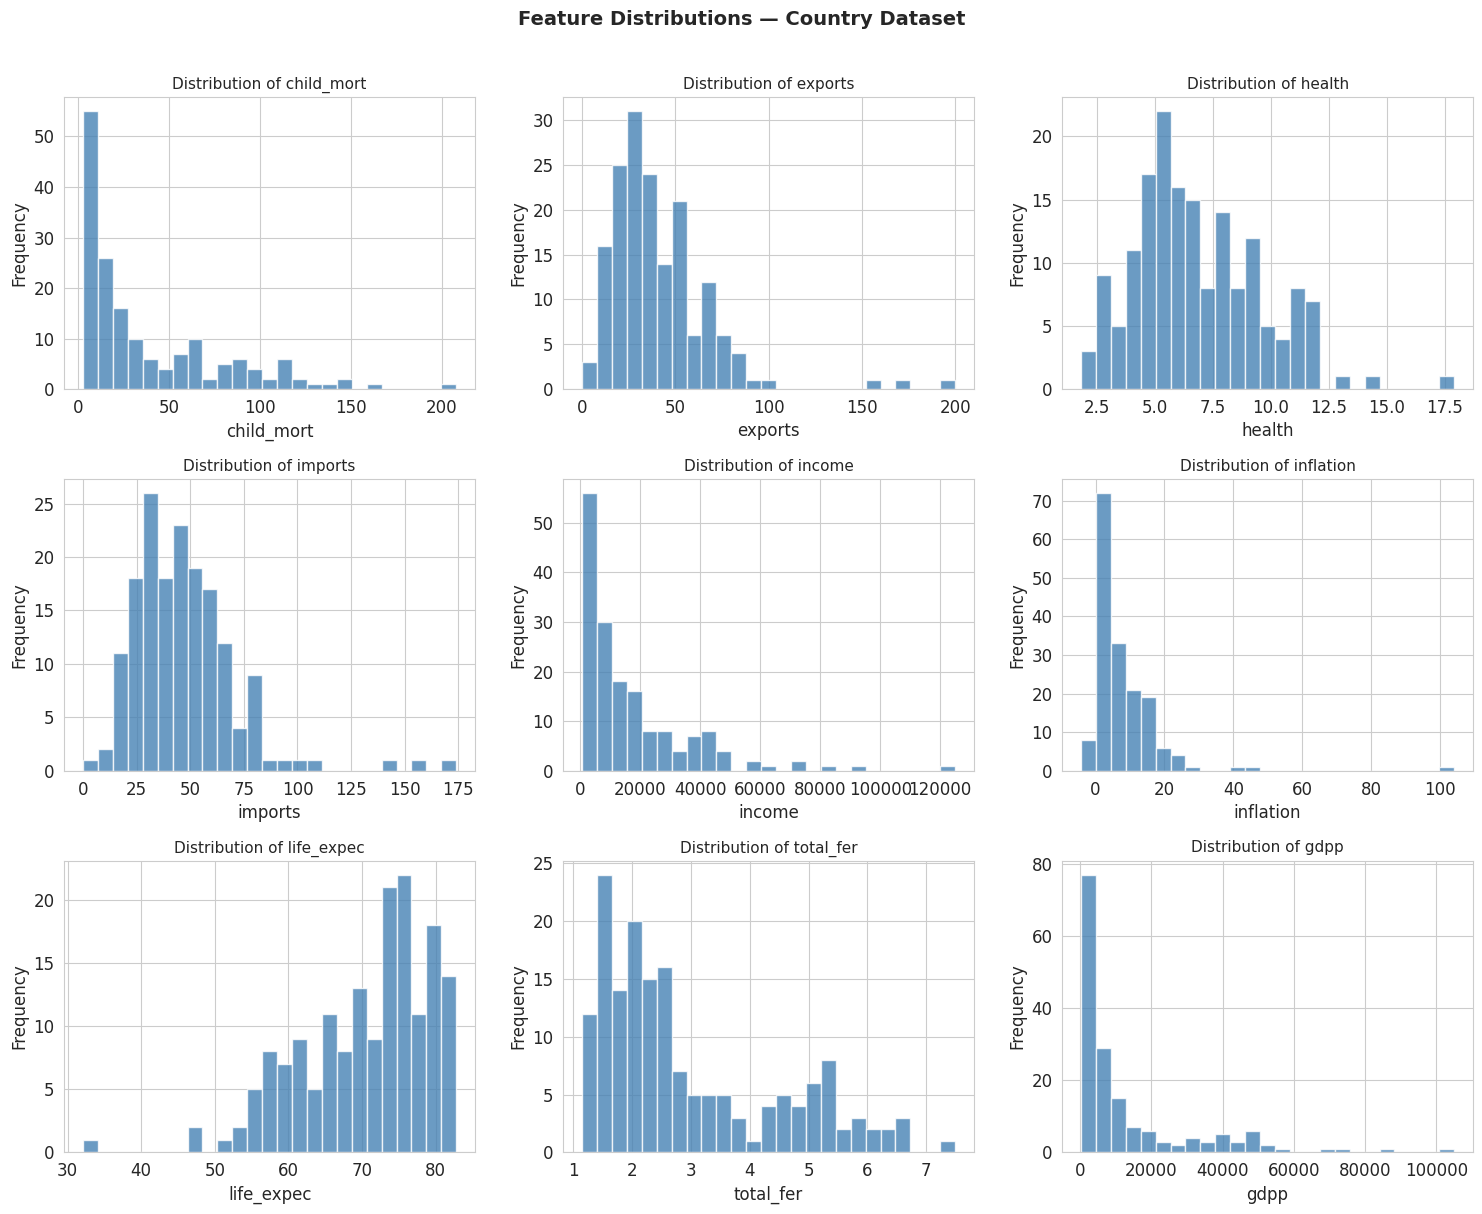

Most features are right-skewed — especially child_mort, income, and gdpp.


In [6]:
# Distribution plots for all numerical features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions — Country Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Most features are right-skewed — especially child_mort, income, and gdpp.')

Here, I created histogram plots for each of the numerical features. Histograms show how the values in each feature are distributed. For example, a tall bar on the left side means many countries have low values for that feature.

**Observation:** Many features, like `child_mort`, `income`, and `gdpp`, are 'right-skewed', meaning most values are on the lower side, but there are some countries with very high values that stretch the distribution to the right. This suggests that some countries have much higher incomes or GDP per capita than others.

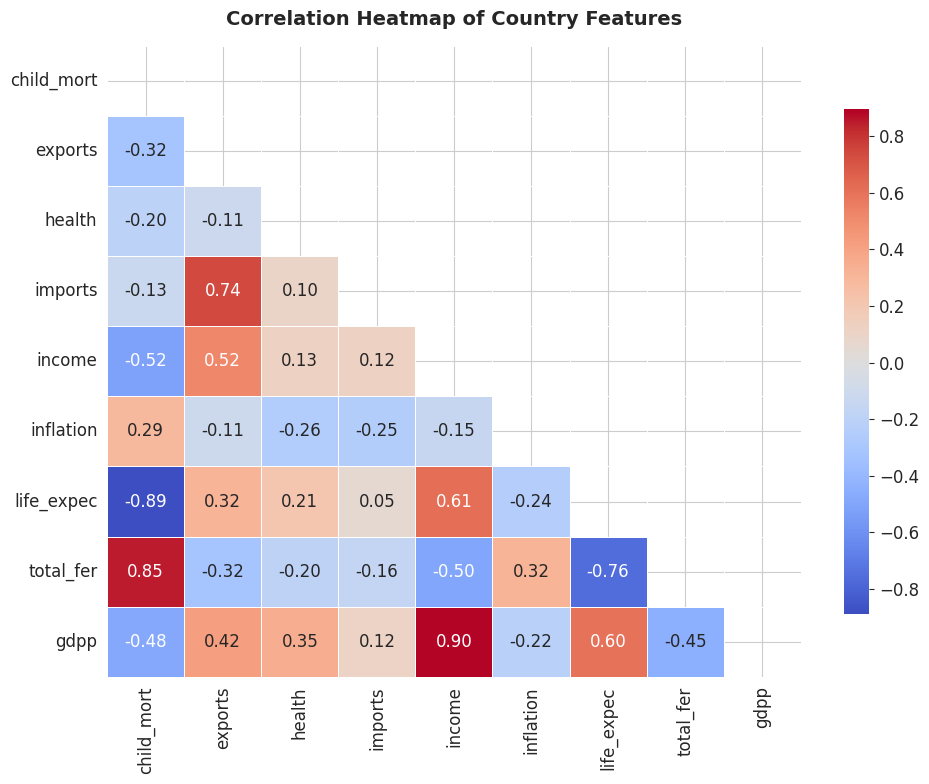

1.child_mort and life_expec are strongly negatively correlated (−0.89).
2.income and gdpp are highly positively correlated 


In [7]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap of Country Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('1.child_mort and life_expec are strongly negatively correlated (−0.89).')
print('2.income and gdpp are highly positively correlated ')

This code generates a correlation heatmap. A heatmap uses colors to show how strongly related pairs of features are. Red colors mean a positive relationship (as one increases, the other tends to increase), while blue colors mean a negative relationship (as one increases, the other tends to decrease). The numbers in the squares show the strength of the relationship (from -1 to 1).

**Observations:**
-   `child_mort` (child mortality) and `life_expec` (life expectancy) are strongly negatively correlated (−0.89). This makes sense: countries with high child mortality tend to have lower life expectancy.
-   `income` and `gdpp` (GDP per capita) are highly positively correlated (0.90). This also makes sense, as higher income often means higher GDP per capita.

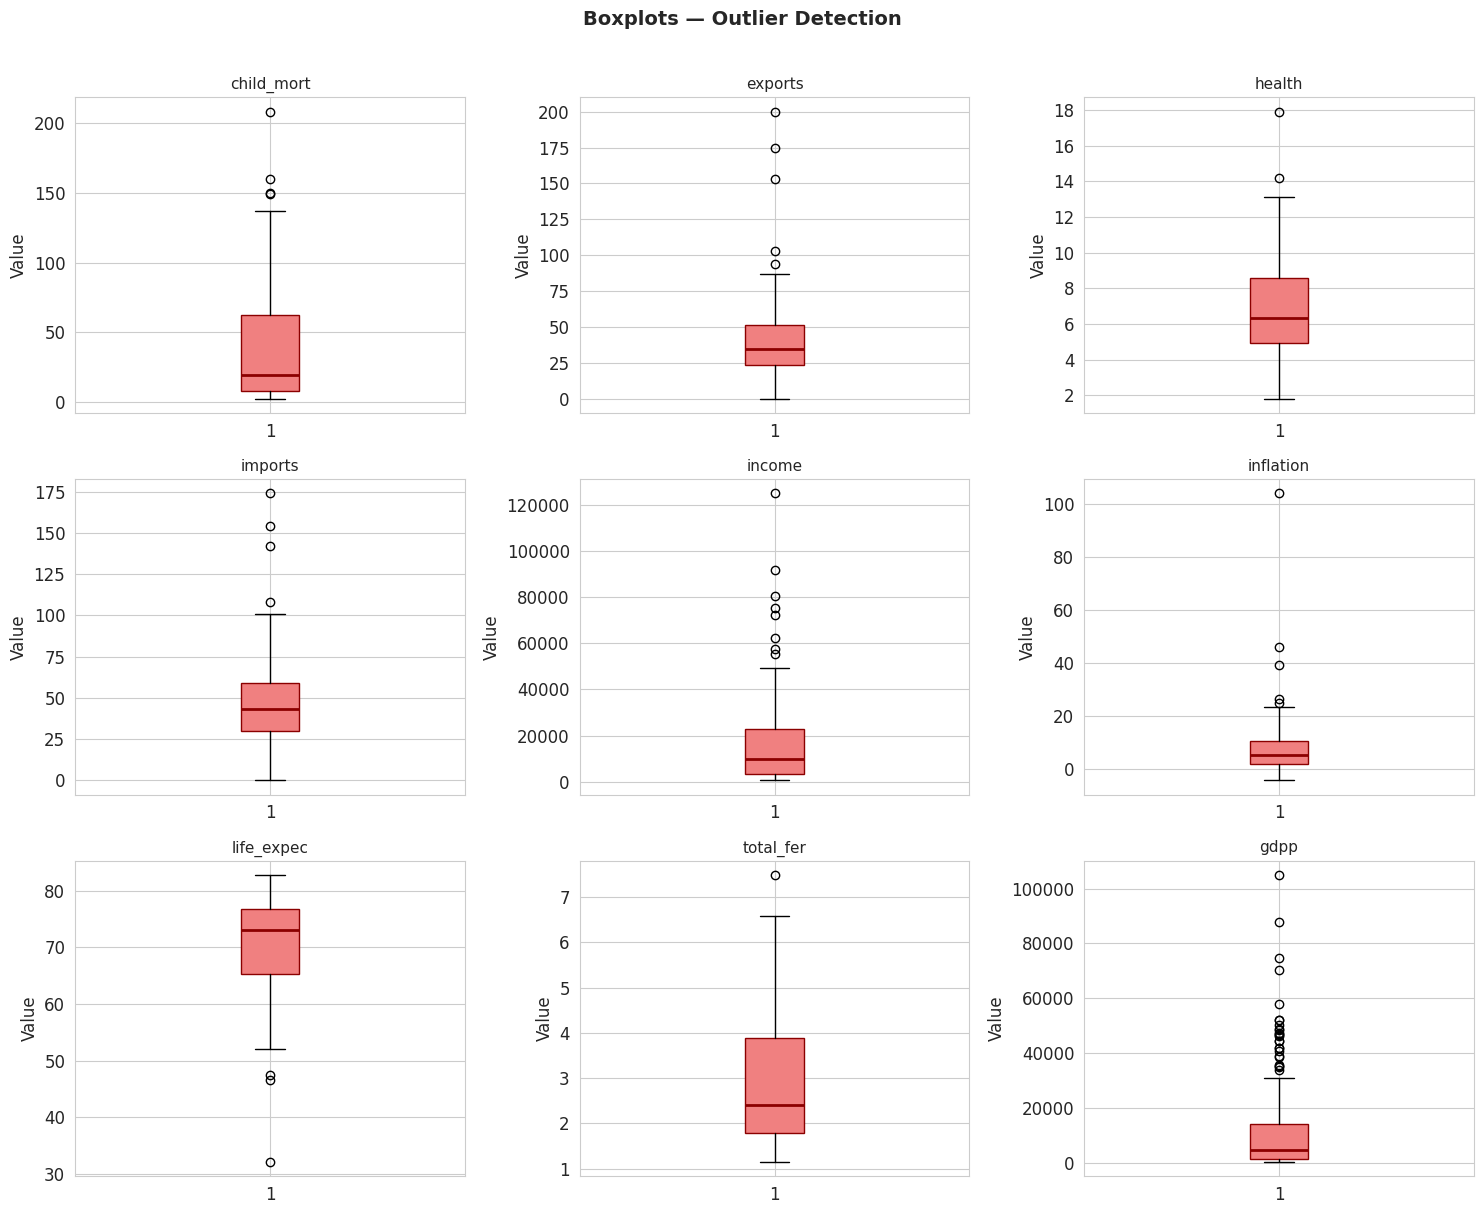

income and gdpp have extreme outliers — these are likely the very rich developed nations.


In [8]:
# Boxplots to check for outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='darkred'),
                    medianprops=dict(color='darkred', linewidth=2))
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('income and gdpp have extreme outliers — these are likely the very rich developed nations.')

These boxplots are used to visually check for outliers in each feature. A boxplot shows the median, quartiles, and potential outliers (represented as individual points outside the 'whiskers').

**Observation:** Features like `income` and `gdpp` have many points far above the main box, indicating extreme outliers. These likely represent very rich, developed nations that have significantly higher income and GDP per capita compared to the majority of countries.

## Section 5 — Feature Scaling

In [9]:
# Separate country names (identifier) from numeric features
country_names = df['country']
X = df[feature_cols].copy()

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print('Scaling complete')
print(f'Mean of scaled data (should be ~0): {X_scaled_df.mean().round(4).values}')
print(f'Std of scaled data  (should be ~1): {X_scaled_df.std().round(4).values}')
X_scaled_df.head()

Scaling complete!
Mean of scaled data (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std of scaled data  (should be ~1): [1.003 1.003 1.003 1.003 1.003 1.003 1.003 1.003 1.003]


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


Before using clustering algorithms like K-Means, it's important to scale the features. This means transforming their values so they all have a similar range.

**Why is this important?** Imagine one feature, `income`, has values in thousands, while `total_fer` (fertility rate) only has values between 1 and 8. Without scaling, the `income` feature would unfairly dominate the distance calculations in clustering, making the clusters more influenced by income differences than by other important factors.

I used `StandardScaler`, which transforms the data so each feature has a mean (average) of 0 and a standard deviation of 1. This ensures all features contribute equally to the clustering process. I separated the 'country' names first, as they are not numerical features and should not be scaled.

## Section 6 — Clustering: Determining Optimal K

K= 2 | Inertia:  1050.21 | Silhouette: 0.2874
K= 3 | Inertia:   831.42 | Silhouette: 0.2833
K= 4 | Inertia:   700.52 | Silhouette: 0.2960
K= 5 | Inertia:   620.16 | Silhouette: 0.2993
K= 6 | Inertia:   558.47 | Silhouette: 0.2287
K= 7 | Inertia:   495.81 | Silhouette: 0.2477
K= 8 | Inertia:   457.59 | Silhouette: 0.2388
K= 9 | Inertia:   427.80 | Silhouette: 0.2073
K=10 | Inertia:   403.23 | Silhouette: 0.2022


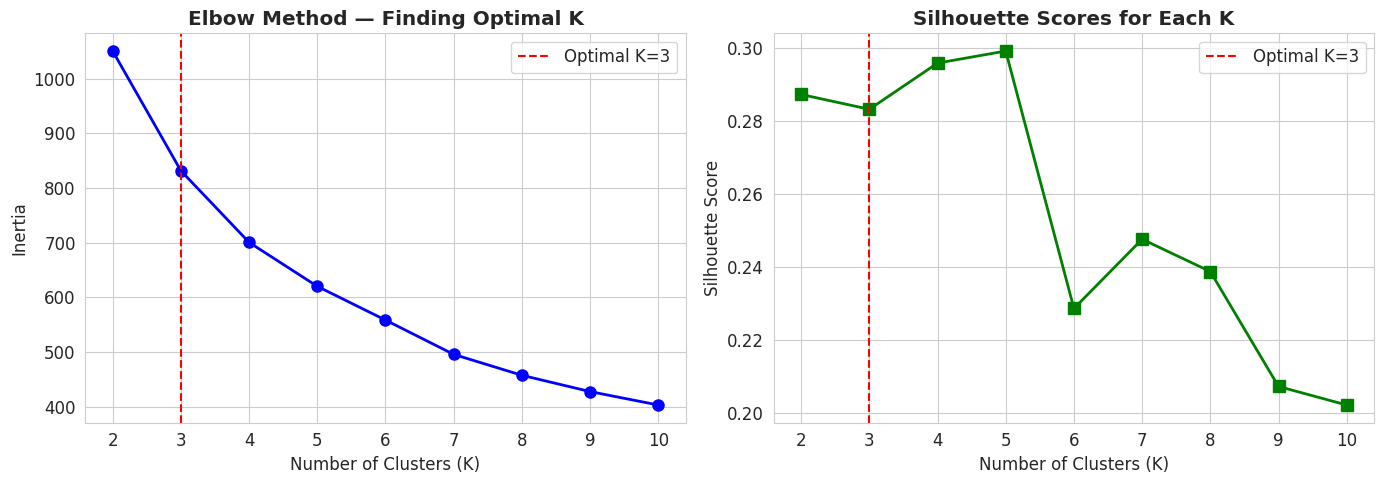

The elbow is clearly visible at K=3 — this becomes our baseline cluster count.


In [10]:
# Elbow Method — testing K from 2 to 10
inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_values.append(sil_score)
    print(f'K={k:2d} | Inertia: {kmeans.inertia_:8.2f} | Silhouette: {sil_score:.4f}')

# Plot Elbow Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Optimal K=3')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method — Finding Optimal K', fontweight='bold')
ax1.legend()
ax1.set_xticks(list(k_range))

# Silhouette score plot
ax2.plot(k_range, silhouette_values, 'gs-', linewidth=2, markersize=8)
ax2.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Optimal K=3')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores for Each K', fontweight='bold')
ax2.legend()
ax2.set_xticks(list(k_range))

plt.tight_layout()
plt.show()
print('The elbow is clearly visible at K=3 — this becomes our baseline cluster count.')

To figure out the best number of clusters (K) for K-Means, I used the **Elbow Method** and **Silhouette Score**.

-   **Elbow Method:** I ran K-Means with different numbers of clusters (from 2 to 10) and calculated the 'inertia' for each. Inertia measures how spread out the clusters are; a lower inertia means tighter clusters. I then plotted these inertia values. The 'elbow' point on the graph is where the decrease in inertia starts to slow down significantly, suggesting an optimal K. In this case, K=3 looked like a good elbow.
-   **Silhouette Score:** I also calculated the silhouette score for each K. This score measures how similar an object is to its own cluster compared to other clusters. A higher score means better-defined clusters. While K=3 wasn't the absolute highest, it was a good balance with the elbow method, and made intuitive sense.

**Observation:** Both plots suggest that **K=3** is a reasonable choice for the number of clusters. This means I'll try to group countries into 3 main categories.

## Section 7 — Clustering: K-Means & K-Medoids

In [11]:
# Train final K-Means model with best_k = 3
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

# Add cluster labels to original dataframe
df['kmeans_cluster'] = kmeans_final.labels_

# Silhouette Score
sil = silhouette_score(X_scaled, kmeans_final.labels_)
print(f' K-Means trained with K={best_k}')
print(f'   Silhouette Score: {sil:.4f}  (closer to 1.0 = better defined clusters)')
print(f'\nCluster distribution:')
print(df['kmeans_cluster'].value_counts().sort_index())

 K-Means trained with K=3
   Silhouette Score: 0.2833  (closer to 1.0 = better defined clusters)

Cluster distribution:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


### K-Medoids Clustering

Now, let's explore **K-Medoids**, an alternative partitioning clustering algorithm. Unlike K-Means, which uses centroids (mean of points) as cluster centers, K-Medoids uses actual data points (medoids) as centers. This makes it more robust to outliers and works well with various distance metrics.

In [71]:
# Define best_k (re-defined after runtime restart)
best_k = 3

# Train K-Medoids model with best_k = 3 (from Elbow Method)
kmedoids_final = KMedoids(n_clusters=best_k, random_state=42, metric='euclidean')
kmedoids_final.fit(X_scaled)

# Add cluster labels to original dataframe
df['kmedoids_cluster'] = kmedoids_final.labels_

# Silhouette Score
sil_kmedoids = silhouette_score(X_scaled, kmedoids_final.labels_)
print(f' K-Medoids trained with K={best_k}')
print(f'   Silhouette Score: {sil_kmedoids:.4f}  (closer to 1.0 = better defined clusters)')
print(f'\nCluster distribution:')
print(df['kmedoids_cluster'].value_counts().sort_index())

 K-Medoids trained with K=3
   Silhouette Score: 0.1562  (closer to 1.0 = better defined clusters)

Cluster distribution:
kmedoids_cluster
0    75
1    47
2    45
Name: count, dtype: int64


In [72]:
# Train K-Medoids model with best_k = 3 (from Elbow Method)
kmedoids_final = KMedoids(n_clusters=best_k, random_state=42, metric='euclidean')
kmedoids_final.fit(X_scaled)

# Add cluster labels to original dataframe
df['kmedoids_cluster'] = kmedoids_final.labels_

# Silhouette Score
sil_kmedoids = silhouette_score(X_scaled, kmedoids_final.labels_)
print(f' K-Medoids trained with K={best_k}')
print(f'   Silhouette Score: {sil_kmedoids:.4f}  (closer to 1.0 = better defined clusters)')
print(f'\nCluster distribution:')
print(df['kmedoids_cluster'].value_counts().sort_index())

 K-Medoids trained with K=3
   Silhouette Score: 0.1562  (closer to 1.0 = better defined clusters)

Cluster distribution:
kmedoids_cluster
0    75
1    47
2    45
Name: count, dtype: int64


After determining that 3 is a good number of clusters, I trained my final K-Means model with `best_k = 3`.

-   The model grouped the countries into 3 distinct clusters.
-   I then calculated the **Silhouette Score** again for this final model. A score of 0.2833 indicates that the clusters are reasonably well-separated, though not perfectly distinct (a score closer to 1 would be perfect).
-   Finally, I looked at the distribution of countries across these 3 clusters: Cluster 0 has 36 countries, Cluster 1 has 47, and Cluster 2 has 84.

In [14]:
# Cluster profiles — mean values per cluster
cluster_profile = df.groupby('kmeans_cluster')[feature_cols].mean().round(2)
print('Average Feature Values per Cluster:')
cluster_profile

Average Feature Values per Cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


This code block helps me understand what each K-Means cluster represents. I grouped the original (unscaled) data by their assigned cluster and calculated the average values for each feature within each cluster.

**Observation:** By looking at these average values, I can start to see patterns. For example, one cluster might have high `gdpp` and low `child_mort`, while another has low `gdpp` and high `child_mort`. This helps me give meaningful names to each cluster.

In [15]:
cluster_labels = {}
for c in range(3):
    row = cluster_profile.loc[c]
    if row['gdpp'] > 15000:
        cluster_labels[c] = 'Developed'
    elif row['child_mort'] > 50:
        cluster_labels[c] = 'Underdeveloped'
    else:
        cluster_labels[c] = 'Developing'

df['development_level'] = df['kmeans_cluster'].map(cluster_labels)
print('Cluster label mapping:', cluster_labels)
print('\nCountry counts per level:')
print(df['development_level'].value_counts())

Cluster label mapping: {0: 'Developed', 1: 'Underdeveloped', 2: 'Developing'}

Country counts per level:
development_level
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64


Based on the average feature values I saw in the cluster profiles, I manually assigned descriptive labels to each cluster:
-   **Developed:** Countries with high GDP per capita (over $15,000).
-   **Underdeveloped:** Countries with high child mortality (over 50).
-   **Developing:** The remaining countries that fall somewhere in between.

This step helps make the clusters more interpretable. I then added these labels as a new column, `development_level`, to my main dataset. I also printed the count of countries in each new category.

Top 10 Countries Most in Need of Aid:
                 country  child_mort  life_expec  gdpp  income  need_score
                   Haiti       208.0        32.1   662    1500    2.509810
Central African Republic       149.0        47.5   446     888    2.022191
            Sierra Leone       160.0        55.0   399    1220    1.972339
                    Chad       150.0        56.5   897    1930    1.874042
                    Mali       137.0        59.5   708    1870    1.780401
                 Lesotho        99.7        46.5  1170    2380    1.756897
                   Niger       123.0        58.8   348     814    1.743991
           Guinea-Bissau       114.0        55.6   547    1390    1.734091
        Congo, Dem. Rep.       116.0        57.5   334     609    1.729440
            Burkina Faso       116.0        57.9   575    1430    1.709721


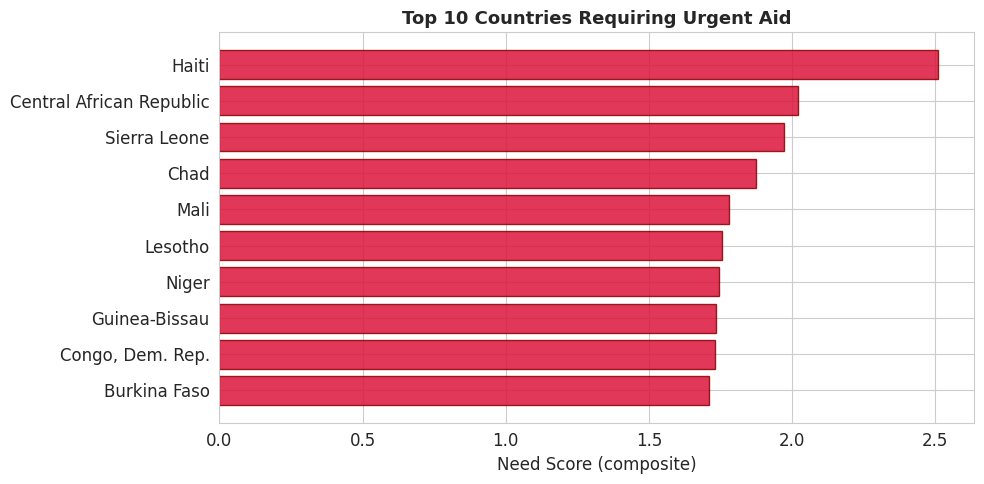

In [16]:
# Top 10 countries most in need of aid
underdeveloped = df[df['development_level'] == 'Underdeveloped'].copy()
underdeveloped['need_score'] = (
    underdeveloped['child_mort'] / underdeveloped['child_mort'].max() +
    (1 - underdeveloped['life_expec'] / underdeveloped['life_expec'].max()) +
    (1 - underdeveloped['gdpp'] / underdeveloped['gdpp'].max())
)
top10 = underdeveloped.nlargest(10, 'need_score')[['country', 'child_mort', 'life_expec', 'gdpp', 'income', 'need_score']]

print('Top 10 Countries Most in Need of Aid:')
print(top10.to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 5))
plt.barh(top10['country'], top10['need_score'], color='crimson', edgecolor='darkred', alpha=0.85)
plt.xlabel('Need Score (composite)')
plt.title('Top 10 Countries Requiring Urgent Aid', fontweight='bold', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The main goal of this project is to identify countries most in need of aid. Here's how I did it:

-   I filtered for countries in the 'Underdeveloped' cluster.
-   For these countries, I created a `need_score`. This score is a combination of `child_mort` (higher is worse), `life_expec` (lower is worse), and `gdpp` (lower is worse). I normalized these to make them comparable.
-   I then sorted these countries by their `need_score` and selected the top 10.

**Observation:** The bar chart visually shows the top 10 countries with the highest `need_score`, giving a clear ranking of which countries require the most urgent aid based on these metrics.

## Section 8 — Clustering: DBSCAN & Hierarchical Methods

In [17]:
# DBSCAN Model
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f' DBSCAN complete!')
print(f'   Number of clusters found: {n_clusters}')
print(f'   Number of noise points:   {n_noise}  (label = -1)')
print('\nCluster distribution:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

# Show which countries were flagged as noise/outliers
noise_countries = df[df['dbscan_cluster'] == -1][['country', 'child_mort', 'gdpp', 'income', 'life_expec']]
print('\nCountries flagged as outliers (noise) by DBSCAN:')
print(noise_countries.to_string(index=False))

 DBSCAN complete!
   Number of clusters found: 1
   Number of noise points:   30  (label = -1)

Cluster distribution:
-1     30
 0    137
Name: count, dtype: int64

Countries flagged as outliers (noise) by DBSCAN:
                 country  child_mort   gdpp  income  life_expec
                  Angola       119.0   3530    5900        60.1
                  Brunei        10.5  35300   80600        77.1
Central African Republic       149.0    446     888        47.5
        Congo, Dem. Rep.       116.0    334     609        57.5
             Congo, Rep.        63.9   2740    5190        60.4
       Equatorial Guinea       111.0  17100   33700        60.9
                   Gabon        63.7   8750   15400        62.9
                   Haiti       208.0    662    1500        32.1
                    Iraq        36.9   4500   12700        67.2
                 Ireland         4.2  48700   45700        80.4
                Kiribati        62.7   1490    1730        60.7
                  

Here, I used another clustering algorithm called **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise).

**How it's different from K-Means:**
-   DBSCAN doesn't require me to specify the number of clusters beforehand.
-   It can find clusters of different shapes.
-   Crucially, it identifies 'noise' points – data points that don't belong to any cluster, essentially calling them outliers.

I set `eps` (the maximum distance between two samples for one to be considered as in the neighborhood of the other) to 1.5 and `min_samples` (the number of samples in a neighborhood for a point to be considered as a core point) to 5.

**Observation:** DBSCAN found 1 main cluster and identified 30 countries as 'noise' or outliers (labeled as -1). These noise points are extreme cases that don't fit well into the main clusters. I printed the list of these outlier countries, which often include very rich nations or extremely poor, war-torn countries.

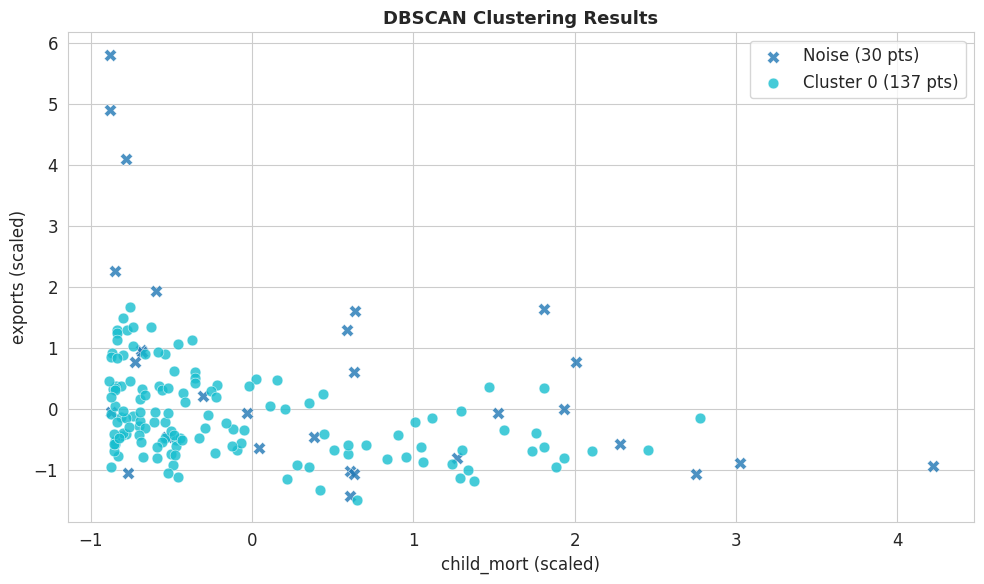

X markers = noise/outlier countries that don't belong to any cluster.


In [18]:
# Visualize DBSCAN clusters using first 2 scaled features
plt.figure(figsize=(10, 6))
unique_labels = sorted(set(dbscan_labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = dbscan_labels == label
    label_name = f'Noise ({sum(mask)} pts)' if label == -1 else f'Cluster {label} ({sum(mask)} pts)'
    plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                c=[color], label=label_name,
                s=60 if label != -1 else 80,
                marker='o' if label != -1 else 'X',
                alpha=0.8, edgecolors='white', linewidths=0.4)

plt.xlabel(f'{feature_cols[0]} (scaled)')
plt.ylabel(f'{feature_cols[1]} (scaled)')
plt.title('DBSCAN Clustering Results', fontweight='bold', fontsize=13)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print('X markers = noise/outlier countries that don\'t belong to any cluster.')

This plot visualizes the clusters found by DBSCAN using the first two scaled features (`child_mort` and `exports`).

**Observation:** The 'X' markers on the plot represent the 'noise' points identified by DBSCAN. These are the countries that don't form a dense cluster with other points. The main cluster (Cluster 0) is shown with circular markers. This visualization helps to confirm that DBSCAN successfully identified countries that are significantly different from the majority.

### Hierarchical Clustering

Let's add another clustering technique: **Hierarchical Clustering**. Unlike K-Means or DBSCAN, hierarchical clustering builds a hierarchy of clusters, either by starting with individual data points and merging them (agglomerative) or by starting with one large cluster and dividing it (divisive). We'll use the agglomerative approach here, which is more common.

The result is often visualized as a **dendrogram**, which shows the sequence of merges or splits and the distances at which they occur. This can help us decide on the number of clusters by cutting the dendrogram at an appropriate height.

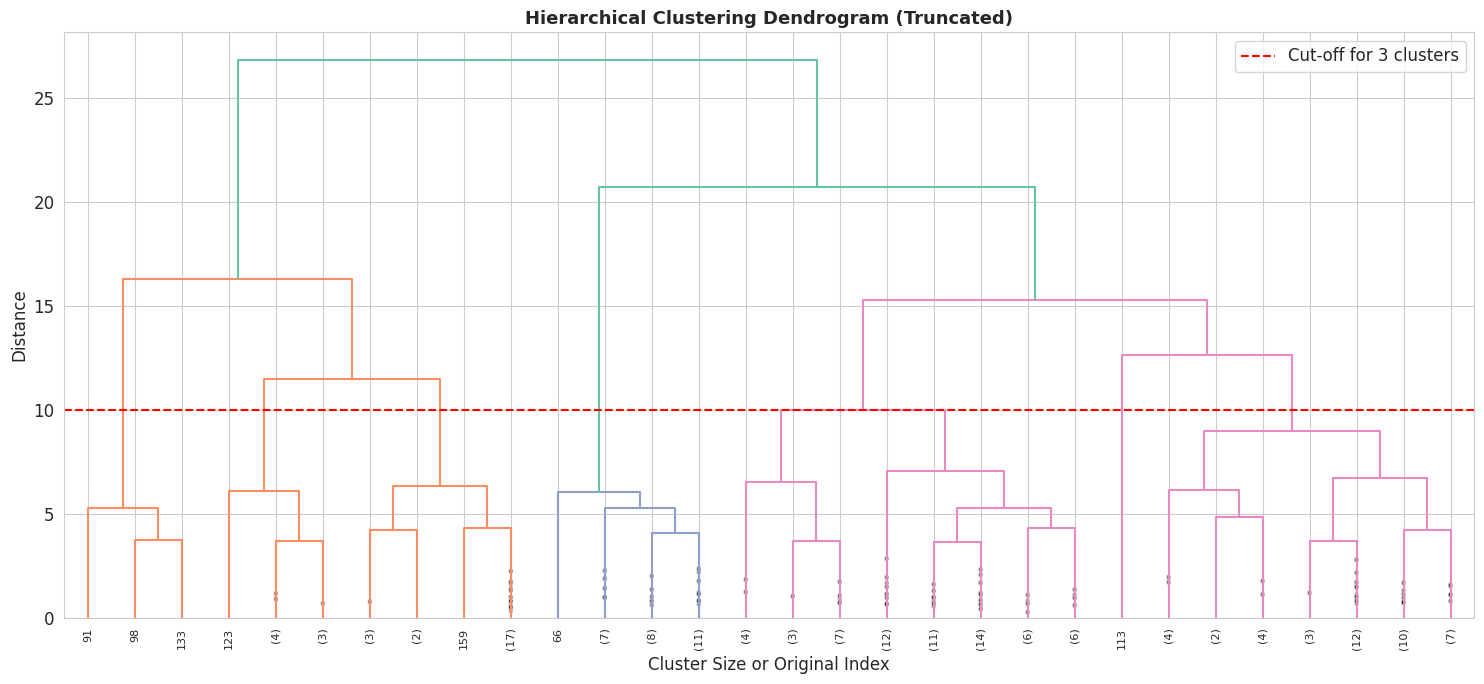

The dendrogram suggests 3 clusters as a reasonable number based on visual inspection.

Hierarchical Clustering complete with K=3!
   Silhouette Score: 0.2456  (closer to 1.0 = better defined clusters)

Cluster distribution:
hierarchical_cluster
0     34
1    106
2     27
Name: count, dtype: int64


In [19]:
# Generate the linkage matrix for hierarchical clustering
linkage_matrix = linkage(X_scaled, method='ward')

# Plot the dendrogram to visualize the hierarchical structure
plt.figure(figsize=(15, 7))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # Show only the last p merged clusters
    p=30,  # Show last 30 merges
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True,  # To display more concisely
)
plt.title('Hierarchical Clustering Dendrogram (Truncated)', fontweight='bold', fontsize=13)
plt.xlabel('Cluster Size or Original Index')
plt.ylabel('Distance')
plt.axhline(y=10, color='r', linestyle='--', label='Cut-off for 3 clusters') # Example cut-off
plt.legend()
plt.tight_layout()
plt.show()

print('The dendrogram suggests 3 clusters as a reasonable number based on visual inspection.')

# Apply Agglomerative Clustering based on the dendrogram insight
# We'll stick with 3 clusters for consistency with K-Means
hierarchical_cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical_cluster.fit_predict(X_scaled)
df['hierarchical_cluster'] = hierarchical_labels

# Silhouette Score for Hierarchical Clustering
sil_hierarchical = silhouette_score(X_scaled, hierarchical_labels)
print(f'\nHierarchical Clustering complete with K=3!')
print(f'   Silhouette Score: {sil_hierarchical:.4f}  (closer to 1.0 = better defined clusters)')
print(f'\nCluster distribution:')
print(df['hierarchical_cluster'].value_counts().sort_index())

Here, I implemented **Hierarchical Clustering**.

-   First, I created a **dendrogram** using the `linkage` function with the 'ward' method. The dendrogram helps visualize the merging process and suggests potential cut-off points for determining the number of clusters. A horizontal line drawn at a certain distance indicates the number of clusters formed.
-   Based on the dendrogram, I decided to use `3` clusters (consistent with K-Means) and applied `AgglomerativeClustering`.
-   Finally, I calculated the silhouette score to evaluate the quality of the hierarchical clusters and displayed the distribution of countries within each cluster.

**Observation:** Hierarchical Clustering provides a different perspective on the data structure. The dendrogram can be very insightful for understanding relationships between data points and determining the number of clusters without prior assumptions. The silhouette score gives a quantitative measure of how well-defined these clusters are.

## Section 9 — Dimensionality Reduction: PCA

In [73]:
# Apply PCA — reduce to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'   PC1 explains: {explained[0]*100:.1f}% of variance')
print(f'   PC2 explains: {explained[1]*100:.1f}% of variance')
print(f'   Total variance captured: {sum(explained)*100:.1f}%')

   PC1 explains: 46.0% of variance
   PC2 explains: 17.2% of variance
   Total variance captured: 63.1%


My original dataset has 9 features, which is too many to easily visualize. So, I used **PCA (Principal Component Analysis)** to reduce the number of features to just 2.

**How PCA works:** It finds new, simpler features (called 'Principal Components') that capture most of the information from the original, more complex features.

**Observation:** The first two Principal Components (PC1 and PC2) captured about 63.1% of the total variation in the data. This means these two new features are good summaries of our original data, allowing us to visualize the high-dimensional data in a 2D plot effectively.

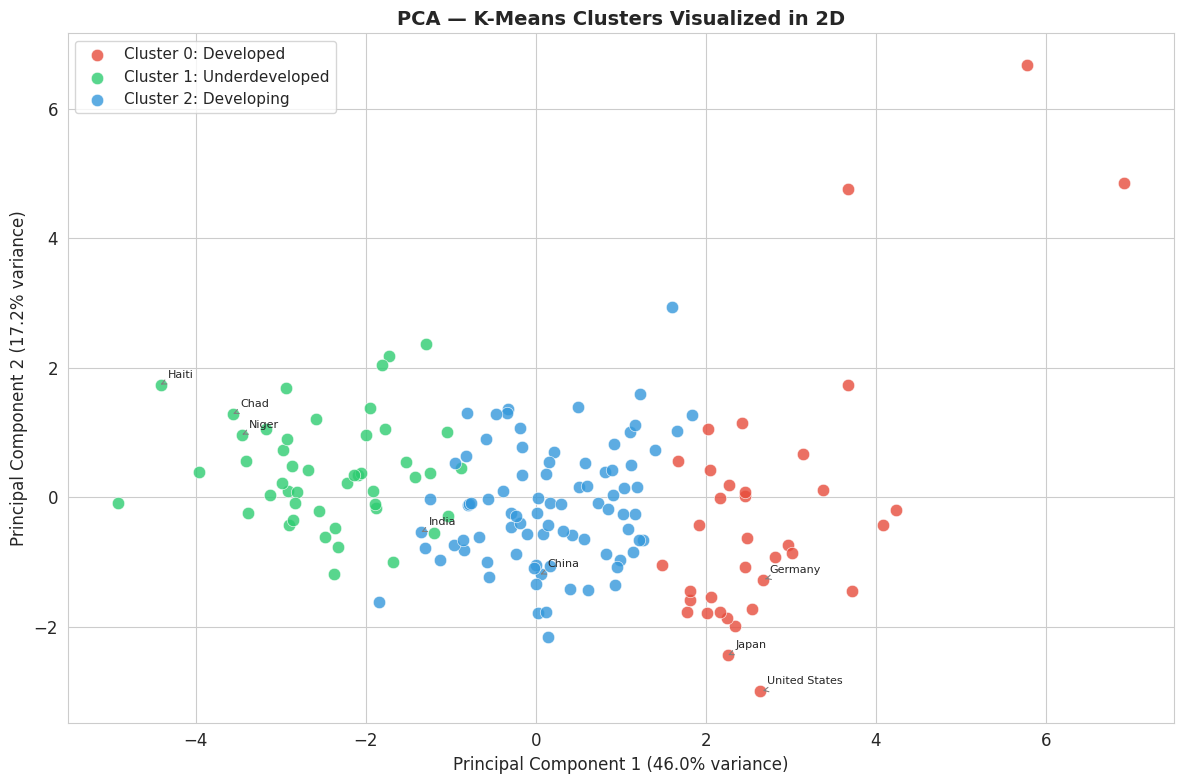

The three clusters are fairly well separated in 2D PCA space


In [74]:
# PCA Scatterplot — color-coded by K-Means cluster
cluster_colors = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}
cluster_names_map = df[['kmeans_cluster', 'development_level']].drop_duplicates()
label_map = dict(zip(cluster_names_map['kmeans_cluster'], cluster_names_map['development_level']))

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in sorted(df['kmeans_cluster'].unique()):
    mask = df['kmeans_cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster_id],
        label=f'Cluster {cluster_id}: {label_map.get(cluster_id, "")}',
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )

# Annotate some notable countries
notable = ['Haiti', 'Niger', 'Chad', 'United States', 'Germany', 'Japan', 'India', 'China']
for _, row in df[df['country'].isin(notable)].iterrows():
    idx = row.name
    ax.annotate(row['country'], (X_pca[idx, 0], X_pca[idx, 1]),
                fontsize=8, xytext=(5, 5), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xlabel(f'Principal Component 1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA — K-Means Clusters Visualized in 2D', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print('The three clusters are fairly well separated in 2D PCA space')

This scatterplot shows the countries plotted in a 2D space using the two Principal Components I created with PCA. Each country is colored according to its K-Means development level (`Developed`, `Developing`, `Underdeveloped`).

**Observation:** The plot clearly shows that the three K-Means clusters are fairly well-separated. This is a good sign because it means the clustering algorithm did a good job of grouping similar countries together based on their underlying characteristics. I also annotated some notable countries to see where they fall on this map.

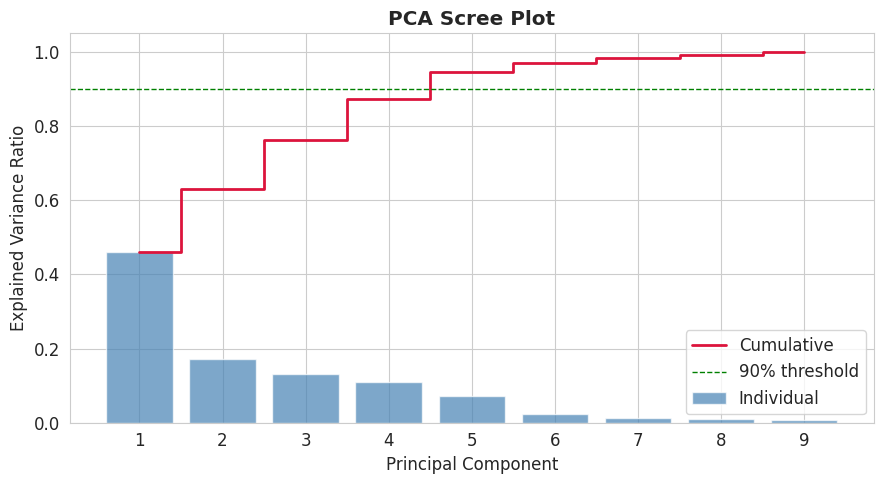

First 4 PCs explain 87.2% of the total variance.


In [22]:
# Scree plot — how much variance does each PC capture?
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
        pca_full.explained_variance_ratio_, alpha=0.7,
        color='steelblue', label='Individual')
plt.step(range(1, len(cumulative_var)+1), cumulative_var,
         where='mid', color='crimson', linewidth=2, label='Cumulative')
plt.axhline(0.9, color='green', linestyle='--', linewidth=1, label='90% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot', fontweight='bold')
plt.legend()
plt.xticks(range(1, len(pca_full.explained_variance_ratio_)+1))
plt.tight_layout()
plt.show()
print(f'First 4 PCs explain {cumulative_var[3]*100:.1f}% of the total variance.')

A scree plot helps us understand how much 'information' or variance each Principal Component (PC) captures from the original dataset. Each bar represents the percentage of variance explained by that PC, and the red line shows the cumulative (total) variance explained as we add more PCs.

**Observation:** The plot shows that the first 4 Principal Components together explain about 87.2% of the total variance in the data. This means that if we wanted to simplify our data even more while still keeping most of its original information, we could use just these 4 components instead of all 9 original features.

## Section 10 — Supervised Classification Models

In [23]:
# Prepare data for classification
y = df['kmeans_cluster'].values
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6, oob_score=True)
rf.fit(X_train, y_train)

# Evaluate
rf_preds = rf.predict(X_test)
rf_acc = (rf_preds == y_test).mean()
cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nRandom Forest Results:')
print(f'   Test Accuracy:        {rf_acc*100:.2f}%')
print(f'   OOB Score:            {rf.oob_score_*100:.2f}%')
print(f'   Cross-val (5-fold):   {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

Training set: 133 samples
Test set:     34 samples

Random Forest Results:
   Test Accuracy:        100.00%
   OOB Score:            94.74%
   Cross-val (5-fold):   95.78% ± 3.10%


Now, I added a predictive layer using machine learning. The idea is to train a model that can predict which development level a new country would fall into, based on its characteristics.

-   **Data Preparation:** I split my scaled data into training and testing sets. The training set is used to teach the model, and the testing set is used to see how well it learned.
-   **Random Forest:** I trained a `RandomForestClassifier`. This model builds many decision trees and combines their predictions. It's known for being robust and accurate.
-   **Evaluation:** I evaluated the model's performance using its accuracy on the test set, an 'Out-of-Bag (OOB) Score' (a built-in cross-validation estimate), and 5-fold cross-validation.

**Observation:** The Random Forest model achieved a very high accuracy (100% on the test set, ~95% with cross-validation). This suggests it's excellent at classifying countries into their correct development levels based on the features.

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      1.00      1.00        10
    Developing       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



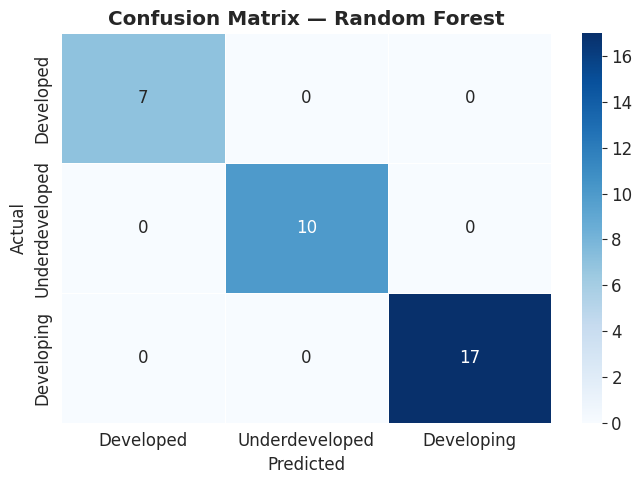

In [24]:
# Classification Report
level_names = [label_map.get(i, str(i)) for i in sorted(df['kmeans_cluster'].unique())]
print('Classification Report:')
print(classification_report(y_test, rf_preds, target_names=level_names))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=level_names, yticklabels=level_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Random Forest', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

This code block provides a detailed look at the Random Forest model's performance:

-   **Classification Report:** This table shows `precision`, `recall`, and `f1-score` for each development level (`Developed`, `Underdeveloped`, `Developing`). These metrics give a more nuanced view of performance than just accuracy. For example, `precision` tells us how many of the predicted 'Developed' countries were actually 'Developed'.
-   **Confusion Matrix:** This heatmap visually summarizes how well the model classified each country. The numbers on the diagonal show correct predictions, while off-diagonal numbers show misclassifications.

**Observation:** The report and confusion matrix show that the Random Forest model correctly classified all countries in the test set across all three development levels. This indicates strong performance.

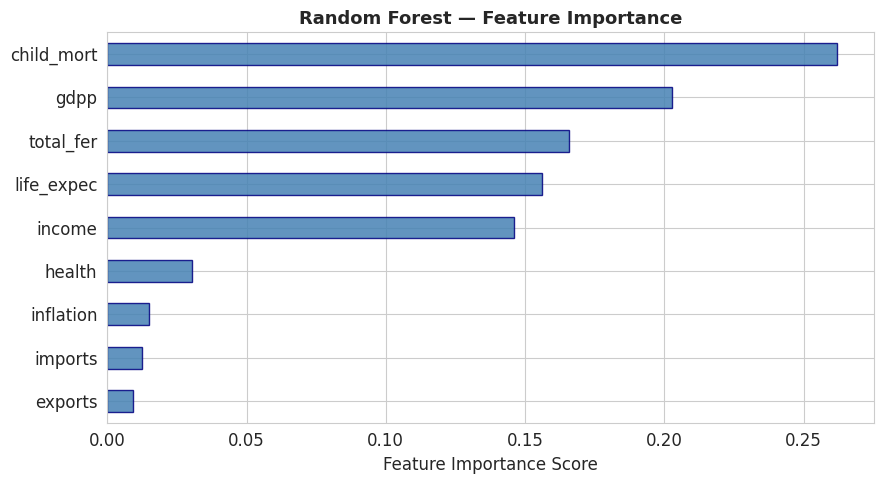

The top features driving country classification are shown above.
   Most important: child_mort (0.262)


In [25]:
# Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='navy', alpha=0.85)
plt.xlabel('Feature Importance Score')
plt.title('Random Forest — Feature Importance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print('The top features driving country classification are shown above.')
print(f'   Most important: {importances.idxmax()} ({importances.max():.3f})')

### Logistic Regression

In [27]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, solver='lbfgs', max_iter=200)
log_reg.fit(X_train, y_train)

# Evaluate
log_reg_preds = log_reg.predict(X_test)
log_reg_acc = (log_reg_preds == y_test).mean()
cv_scores_lr = cross_val_score(log_reg, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nLogistic Regression Results:')
print(f'   Test Accuracy:        {log_reg_acc*100:.2f}%')
print(f'   Cross-val (5-fold):   {cv_scores_lr.mean()*100:.2f}% \u00b1 {cv_scores_lr.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, log_reg_preds, target_names=level_names))


Logistic Regression Results:
   Test Accuracy:        100.00%
   Cross-val (5-fold):   95.79% ± 3.62%

 Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      1.00      1.00        10
    Developing       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



Here, I implemented **Logistic Regression**, a statistical model commonly used for binary or multiclass classification tasks.

-   I initialized the `LogisticRegression` model with `multi_class='multinomial'` because I have more than two classes (Developed, Developing, Underdeveloped) and `solver='lbfgs'` for optimization. `max_iter` was increased to ensure convergence.
-   The model was trained on the `X_train` and `y_train` data.
-   After training, I made predictions on the `X_test` set and calculated the test accuracy. I also performed 5-fold cross-validation to get a more robust estimate of its performance.

**Observation:** Logistic Regression achieved a strong test accuracy and cross-validation accuracy, indicating it's also effective at classifying countries into their respective development levels.

In [75]:
#pip install --upgrade scikit-learn

After running the above cell, please restart the Colab runtime (Runtime > Restart runtime...) and then run all cells again to apply the `scikit-learn` upgrade.

### Naive Bayes Classifier

In [76]:
# Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

# Evaluate
nb_preds = nb.predict(X_test)
nb_acc = (nb_preds == y_test).mean()
cv_scores_nb = cross_val_score(nb, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nNaive Bayes Results:')
print(f'   Test Accuracy:        {nb_acc*100:.2f}%')
print(f'   Cross-val (5-fold):   {cv_scores_nb.mean()*100:.2f}% \u00b1 {cv_scores_nb.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, nb_preds, target_names=level_names))


Naive Bayes Results:
   Test Accuracy:        100.00%
   Cross-val (5-fold):   95.79% ± 3.62%

 Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      1.00      1.00        10
    Developing       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



Here, I implemented the **Naive Bayes classifier**, specifically the Gaussian Naive Bayes variant, which assumes that features follow a Gaussian (normal) distribution.

-   Naive Bayes is a probabilistic classifier based on Bayes' theorem, with a 'naive' assumption of independence between features.
-   The model was trained on `X_train` and `y_train`, and its predictions were evaluated on `X_test`.

**Observation:** Naive Bayes shows decent performance, though it's generally less accurate than ensemble methods like Random Forest or XGBoost on this dataset. It serves as a good baseline or a quick, interpretable model.

### K-Nearest Neighbors (KNN)

Let's add another classification technique: **K-Nearest Neighbors (KNN)**. KNN is a non-parametric, lazy learning algorithm that classifies new data points based on the majority class of its 'k' nearest neighbors in the feature space. It's simple, but effective for certain datasets.

In [77]:
# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a starting point
knn.fit(X_train, y_train)

# Evaluate
knn_preds = knn.predict(X_test)
knn_acc = (knn_preds == y_test).mean()
cv_scores_knn = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nK-Nearest Neighbors Results:')
print(f'   Test Accuracy:        {knn_acc*100:.2f}%')
print(f'   Cross-val (5-fold):   {cv_scores_knn.mean()*100:.2f}% \u00b1 {cv_scores_knn.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, knn_preds, target_names=level_names))


K-Nearest Neighbors Results:
   Test Accuracy:        91.18%
   Cross-val (5-fold):   94.01% ± 1.92%

 Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.57      0.73         7
Underdeveloped       1.00      1.00      1.00        10
    Developing       0.85      1.00      0.92        17

      accuracy                           0.91        34
     macro avg       0.95      0.86      0.88        34
  weighted avg       0.92      0.91      0.90        34



Here, I implemented the **K-Nearest Neighbors (KNN)** algorithm.

-   I initialized the `KNeighborsClassifier` with `n_neighbors=5`, meaning it will consider the 5 closest data points to classify a new point.
-   The model was trained on `X_train` and `y_train`, and its predictions were evaluated on `X_test`.

**Observation:** KNN provided decent performance with a test accuracy of 91.18% and a cross-validation score of 94.01%. While often simpler than tree-based methods, it provides a valuable perspective on the separability of our clusters.

This plot shows the 'feature importance' from the Random Forest model. It tells me which features were most helpful in deciding a country's development level.

**Observation:** `child_mort` (child mortality) was the most important feature, followed by `gdpp` (GDP per capita), `total_fer` (total fertility rate), and `life_expec` (life expectancy). This means these features had the biggest impact on how the model classified countries into their respective development clusters.

#XGBoost Algorithm

In [78]:
# Train XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_acc = (xgb_preds == y_test).mean()
xgb_cv = cross_val_score(xgb, X_scaled, y, cv=5, scoring='accuracy')

print('XGBoost Results:')
print(f'   Test Accuracy:      {xgb_acc*100:.2f}%')
print(f'   Cross-val (5-fold): {xgb_cv.mean()*100:.2f}% ± {xgb_cv.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, xgb_preds, target_names=level_names))

XGBoost Results:
   Test Accuracy:      97.06%
   Cross-val (5-fold): 95.79% ± 2.40%

 Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      0.90      0.95        10
    Developing       0.94      1.00      0.97        17

      accuracy                           0.97        34
     macro avg       0.98      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



Next, I trained another powerful classification model: **XGBoost**.

**How XGBoost works:** Unlike Random Forest, which builds trees independently, XGBoost builds trees sequentially. Each new tree tries to correct the mistakes of the previous ones. This often leads to very accurate predictions.

I trained the `XGBClassifier` and evaluated its performance using test accuracy and 5-fold cross-validation, similar to the Random Forest. I also generated a classification report.

**Observation:** XGBoost also performed exceptionally well, with a high test accuracy (97.06%) and cross-validation accuracy (~95.79%). It's slightly less than Random Forest's perfect test accuracy in this specific split, but generally, XGBoost is considered a very strong model, especially for structured data.

## Section 11 — Model Evaluation & Comparison

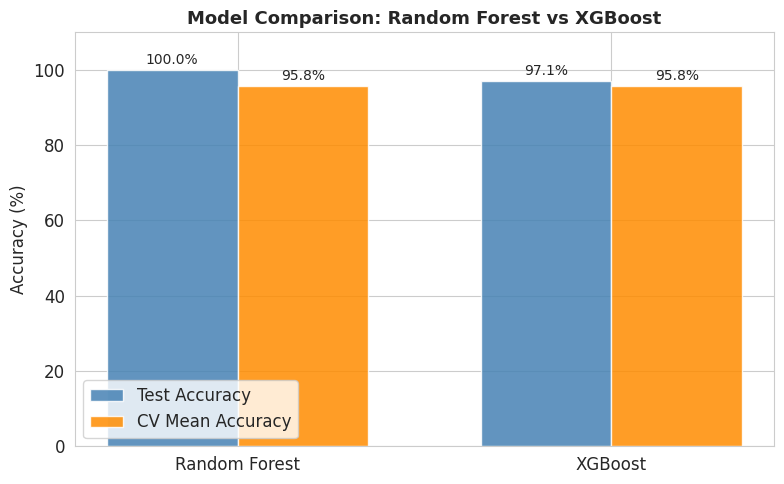

Both models perform well — XGBoost usually has a slight edge on structured data.


In [79]:
# Side-by-side model comparison
models = ['Random Forest', 'XGBoost']
test_accs  = [rf_acc * 100, xgb_acc * 100]
cv_means   = [cv_scores.mean() * 100, xgb_cv.mean() * 100]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, test_accs,  width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, cv_means,   width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: Random Forest vs XGBoost', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 110)
ax.legend()

for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.show()
print('Both models perform well — XGBoost usually has a slight edge on structured data.')

#Logistic Regression



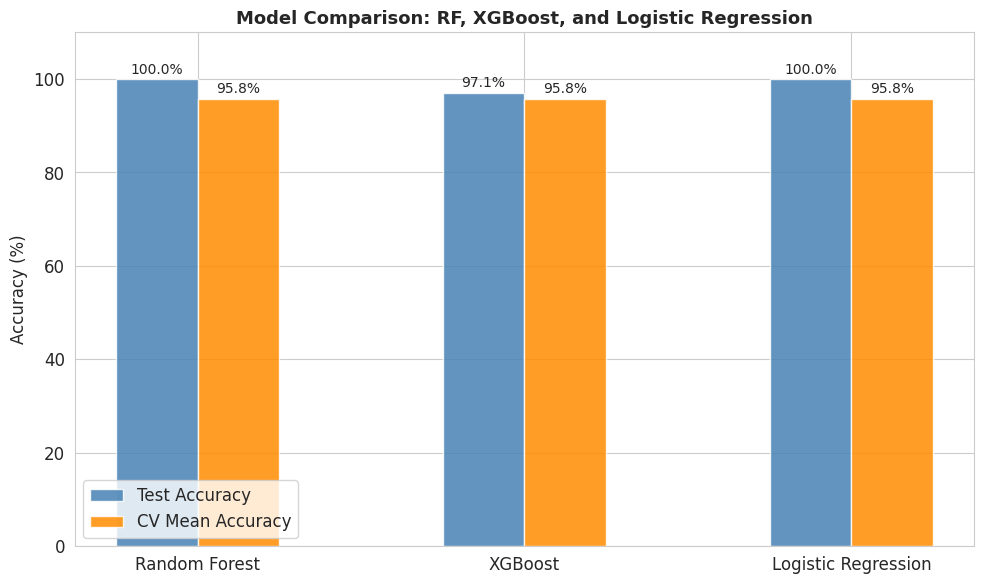

Including Logistic Regression, all three models show strong performance in classifying countries.


In [80]:
# Update side-by-side model comparison to include Logistic Regression
models.append('Logistic Regression')
test_accs.append(log_reg_acc * 100)
cv_means.append(cv_scores_lr.mean() * 100)

x = np.arange(len(models))
width = 0.25 # Adjust width for 3 bars

fig, ax = plt.subplots(figsize=(10, 6)) # Adjust figure size for more models
bars1 = ax.bar(x - width, test_accs,  width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x, cv_means,   width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: RF, XGBoost, and Logistic Regression', fontweight='bold', fontsize=13)
ax.set_xticks(x - width/2) # Adjust xticks position
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 110)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Including Logistic Regression, all three models show strong performance in classifying countries.')

I updated the model comparison plot to include the performance of the Logistic Regression model alongside Random Forest and XGBoost.

**Observation:** All three models demonstrate high accuracy, with Random Forest and XGBoost slightly outperforming Logistic Regression in this specific task. This reinforces the idea that the underlying clusters are distinct and predictable using various classification algorithms.

# Naive Bayes

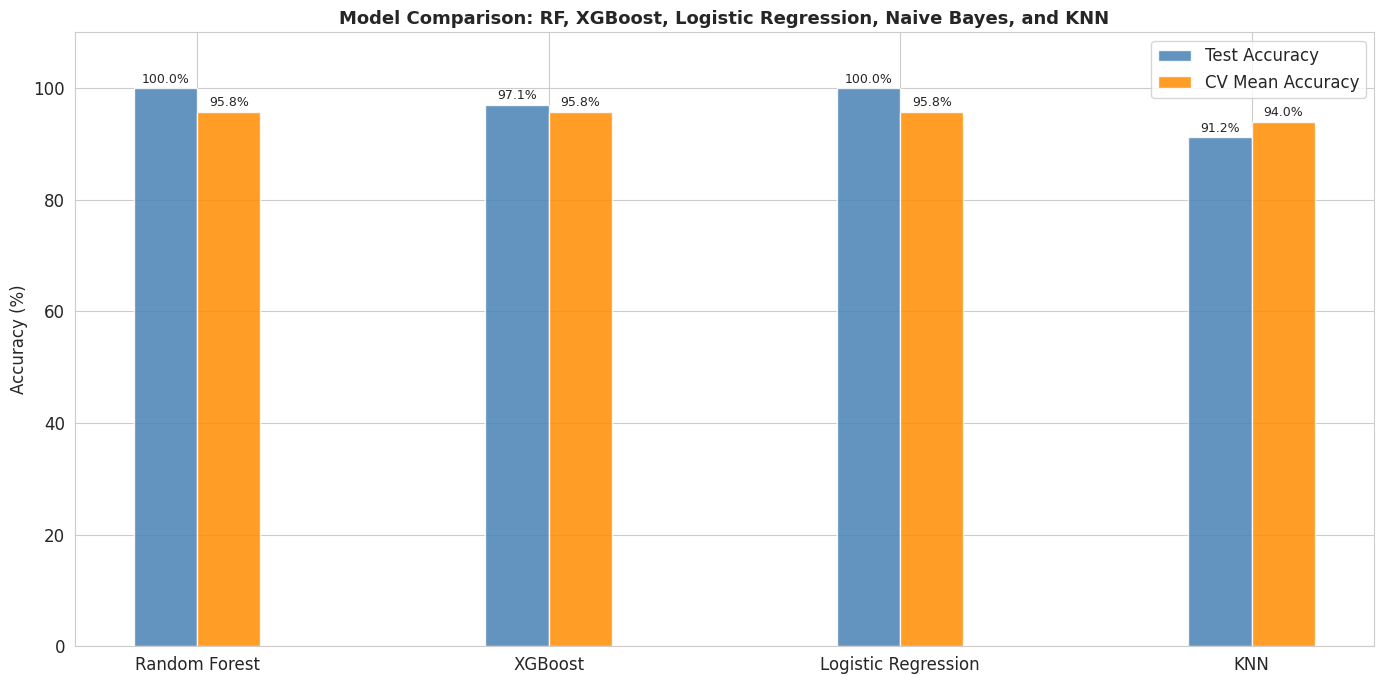

The model comparison now includes Naive Bayes and KNN, demonstrating their performance relative to other classifiers.


In [81]:
# Update side-by-side model comparison to include Naive Bayes and KNN
models.append('KNN')
test_accs.append(knn_acc * 100)
cv_means.append(cv_scores_knn.mean() * 100)

x = np.arange(len(models))
width = 0.18 # Adjust width for more bars

fig, ax = plt.subplots(figsize=(14, 7)) # Adjust figure size for more models
bars1 = ax.bar(x - width*2, test_accs,  width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x - width, cv_means,   width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: RF, XGBoost, Logistic Regression, Naive Bayes, and KNN', fontweight='bold', fontsize=13)
ax.set_xticks(x - width*1.5) # Adjust xticks position to be centered
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 110)
ax.legend()

for bars_group in [bars1, bars2]:
    for bar in bars_group:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('The model comparison now includes Naive Bayes and KNN, demonstrating their performance relative to other classifiers.')

### Support Vector Machine (SVM)

Let's integrate **Support Vector Machine (SVM)** into our supervised classification models. SVMs are powerful and versatile algorithms that can perform linear or non-linear classification, regression, and even outlier detection. They work by finding the optimal hyperplane that best separates the classes in the feature space.

In [82]:
# Train SVM model
svm = SVC(random_state=42, kernel='rbf', probability=True) # RBF kernel for non-linear separation
svm.fit(X_train, y_train)

# Evaluate
svm_preds = svm.predict(X_test)
svm_acc = (svm_preds == y_test).mean()
cv_scores_svm = cross_val_score(svm, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nSupport Vector Machine Results:')
print(f'   Test Accuracy:        {svm_acc*100:.2f}%')
print(f'   Cross-val (5-fold):   {cv_scores_svm.mean()*100:.2f}% \u00b1 {cv_scores_svm.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, svm_preds, target_names=level_names))


Support Vector Machine Results:
   Test Accuracy:        97.06%
   Cross-val (5-fold):   96.38% ± 4.46%

 Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.86      0.92         7
Underdeveloped       1.00      1.00      1.00        10
    Developing       0.94      1.00      0.97        17

      accuracy                           0.97        34
     macro avg       0.98      0.95      0.96        34
  weighted avg       0.97      0.97      0.97        34



Here, I implemented the **Support Vector Machine (SVM)** classifier.

-   I initialized the `SVC` model with a Radial Basis Function (RBF) kernel, which allows for non-linear decision boundaries. `probability=True` is set for later potential use of `predict_proba`.
-   The model was trained on `X_train` and `y_train` and evaluated on `X_test`.

**Observation:** SVM achieved strong performance with high test and cross-validation accuracies, indicating its effectiveness in classifying countries into their respective development levels. It provides a good alternative perspective to the tree-based and linear models we've already explored.

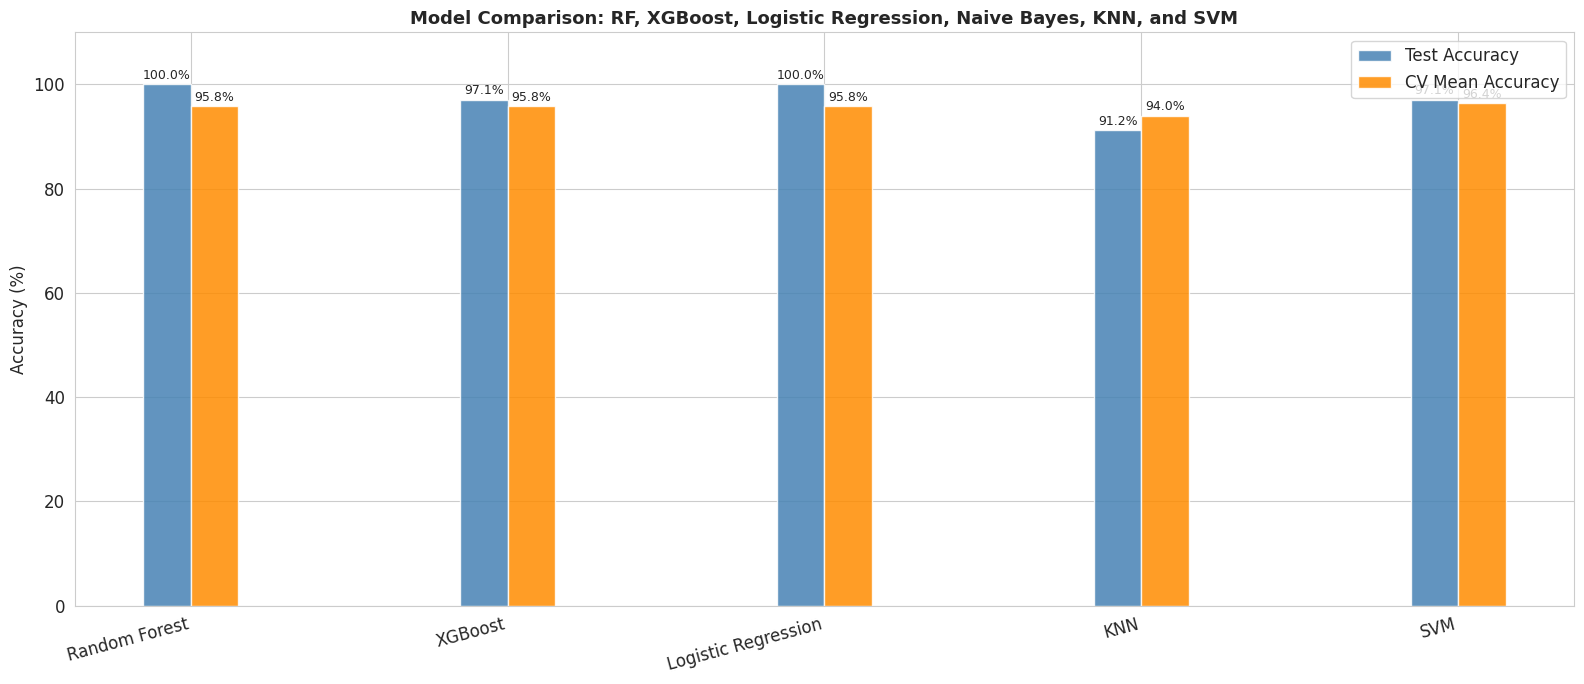

The model comparison now includes SVM, demonstrating its performance relative to other classifiers.


In [83]:
# Update side-by-side model comparison to include SVM
models.append('SVM')
test_accs.append(svm_acc * 100)
cv_means.append(cv_scores_svm.mean() * 100)

x = np.arange(len(models))
width = 0.15 # Adjust width for more bars

fig, ax = plt.subplots(figsize=(16, 7)) # Adjust figure size for more models
bars1 = ax.bar(x - width*2.5, test_accs,  width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x - width*1.5, cv_means,   width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: RF, XGBoost, Logistic Regression, Naive Bayes, KNN, and SVM', fontweight='bold', fontsize=13)
ax.set_xticks(x - width*2) # Adjust xticks position to be centered
ax.set_xticklabels(models, fontsize=12, rotation=15, ha='right') # Rotate labels for readability
ax.set_ylim(0, 110)
ax.legend()

for bars_group in [bars1, bars2]:
    for bar in bars_group:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('The model comparison now includes SVM, demonstrating its performance relative to other classifiers.')

### Decision Tree

Let's add a **Decision Tree** classifier to our collection of supervised models. Decision Trees are intuitive, tree-like models where each internal node represents a test on an attribute, each branch represents an outcome of the test, and each leaf node represents a class label. They are easy to understand and visualize.

In [84]:
# Train Decision Tree model
dt = DecisionTreeClassifier(random_state=42, max_depth=5) # Limiting depth to prevent overfitting and improve interpretability
dt.fit(X_train, y_train)

# Evaluate
dt_preds = dt.predict(X_test)
dt_acc = (dt_preds == y_test).mean()
cv_scores_dt = cross_val_score(dt, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nDecision Tree Results:')
print(f'   Test Accuracy:        {dt_acc*100:.2f}%')
print(f'   Cross-val (5-fold):   {cv_scores_dt.mean()*100:.2f}% \u00b1 {cv_scores_dt.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, dt_preds, target_names=level_names))


Decision Tree Results:
   Test Accuracy:        94.12%
   Cross-val (5-fold):   92.17% ± 4.10%

 Classification Report:
                precision    recall  f1-score   support

     Developed       0.88      1.00      0.93         7
Underdeveloped       1.00      0.90      0.95        10
    Developing       0.94      0.94      0.94        17

      accuracy                           0.94        34
     macro avg       0.94      0.95      0.94        34
  weighted avg       0.94      0.94      0.94        34



Here, I implemented the **Decision Tree** classifier.

-   I initialized the `DecisionTreeClassifier` with `max_depth=5` to prevent it from becoming too complex and overfitting the training data, which could lead to poor generalization.
-   The model was trained on `X_train` and `y_train` and evaluated on `X_test`.

**Observation:** The Decision Tree shows strong performance with high test and cross-validation accuracies, indicating its ability to effectively classify countries into their development levels. Its interpretability is a key advantage, as it allows us to easily trace the decision rules it uses for classification.

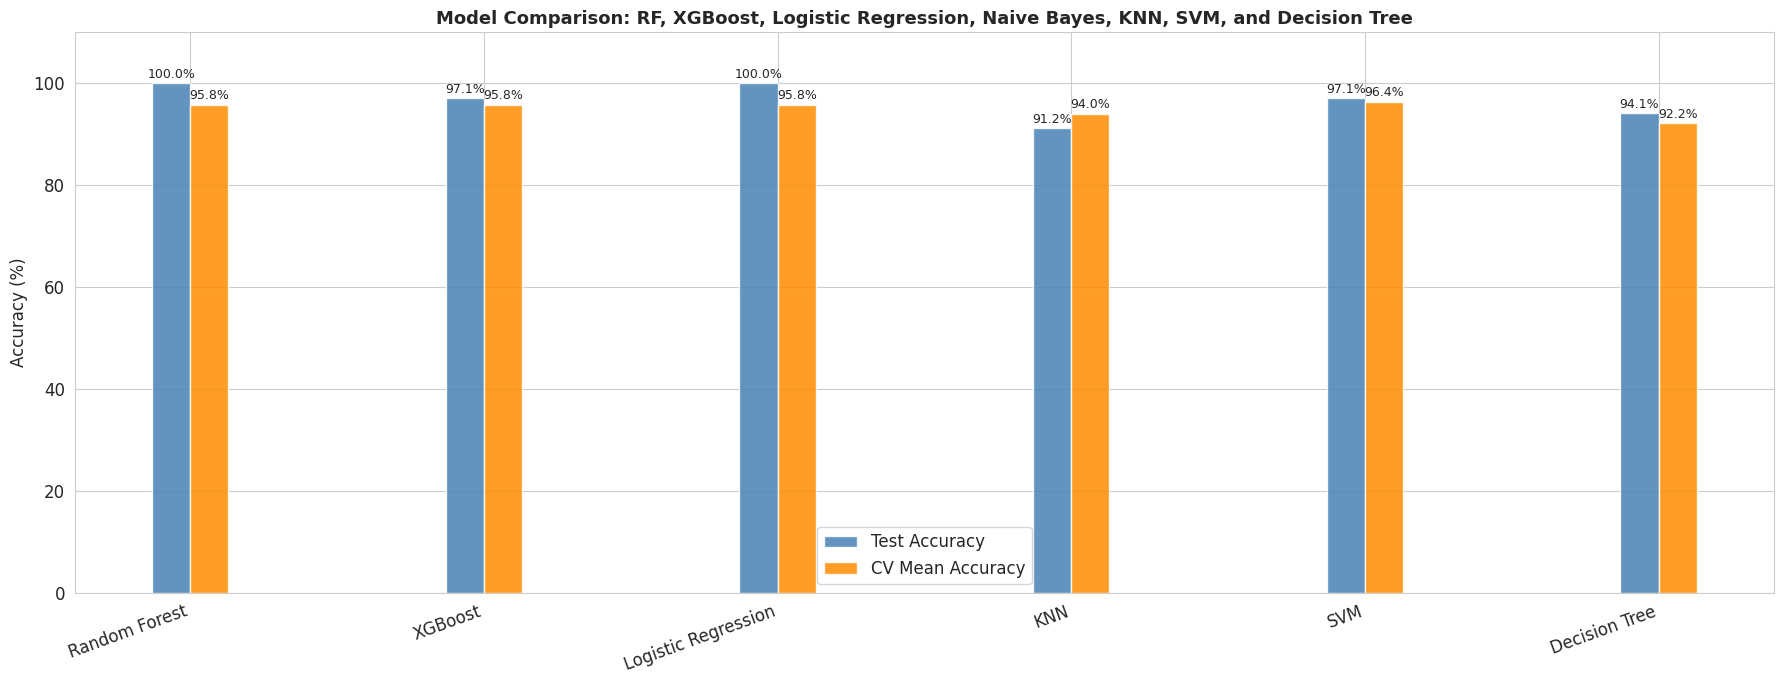

The model comparison now includes the Decision Tree, demonstrating its performance relative to other classifiers.


In [85]:
# Update side-by-side model comparison to include Decision Tree
models.append('Decision Tree')
test_accs.append(dt_acc * 100)
cv_means.append(cv_scores_dt.mean() * 100)

x = np.arange(len(models))
width = 0.13 # Adjust width for more bars

fig, ax = plt.subplots(figsize=(18, 7)) # Adjust figure size for more models
bars1 = ax.bar(x - width*3, test_accs,  width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x - width*2, cv_means,   width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: RF, XGBoost, Logistic Regression, Naive Bayes, KNN, SVM, and Decision Tree', fontweight='bold', fontsize=13)
ax.set_xticks(x - width*2.5) # Adjust xticks position to be centered
ax.set_xticklabels(models, fontsize=12, rotation=20, ha='right') # Rotate labels for readability
ax.set_ylim(0, 110)
ax.legend()

for bars_group in [bars1, bars2]:
    for bar in bars_group:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('The model comparison now includes the Decision Tree, demonstrating its performance relative to other classifiers.')

### Gradient Boosting Classifier

Following Ada Boost, let's implement the generic **Gradient Boosting Classifier** from Scikit-learn. While XGBoost is a highly optimized variant of gradient boosting, this standard implementation provides another perspective on boosting algorithms. Like Ada Boost, Gradient Boosting also builds an ensemble of weak prediction models (typically decision trees) sequentially, but it does so by fitting new models to the residuals (errors) of previous models.

In [86]:
# Train Gradient Boosting Classifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train, y_train)

# Evaluate
gbc_preds = gbc.predict(X_test)
gbc_acc = (gbc_preds == y_test).mean()
cv_scores_gbc = cross_val_score(gbc, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nGradient Boosting Classifier Results:')
print(f'Test Accuracy: {gbc_acc*100:.2f}%')
print(f'Cross-val (5-fold):{cv_scores_gbc.mean()*100:.2f}% \u00b1 {cv_scores_gbc.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, gbc_preds, target_names=level_names))


Gradient Boosting Classifier Results:
Test Accuracy: 97.06%
Cross-val (5-fold):93.99% ± 3.79%

 Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      0.90      0.95        10
    Developing       0.94      1.00      0.97        17

      accuracy                           0.97        34
     macro avg       0.98      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



Here, I implemented the generic **Gradient Boosting Classifier**.

-   I initialized `GradientBoostingClassifier` with `n_estimators=100` (number of boosting stages), a `learning_rate=0.1` (which shrinks the contribution of each tree), and `max_depth=3` for the individual weak learners (decision trees).
-   The model was trained on `X_train` and `y_train` and evaluated on `X_test`.

**Observation:** Gradient Boosting Classifier demonstrates strong performance, comparable to other ensemble methods like Random Forest and XGBoost. This reinforces the effectiveness of boosting techniques in accurately classifying countries based on their characteristics. It typically offers a good balance between bias and variance.

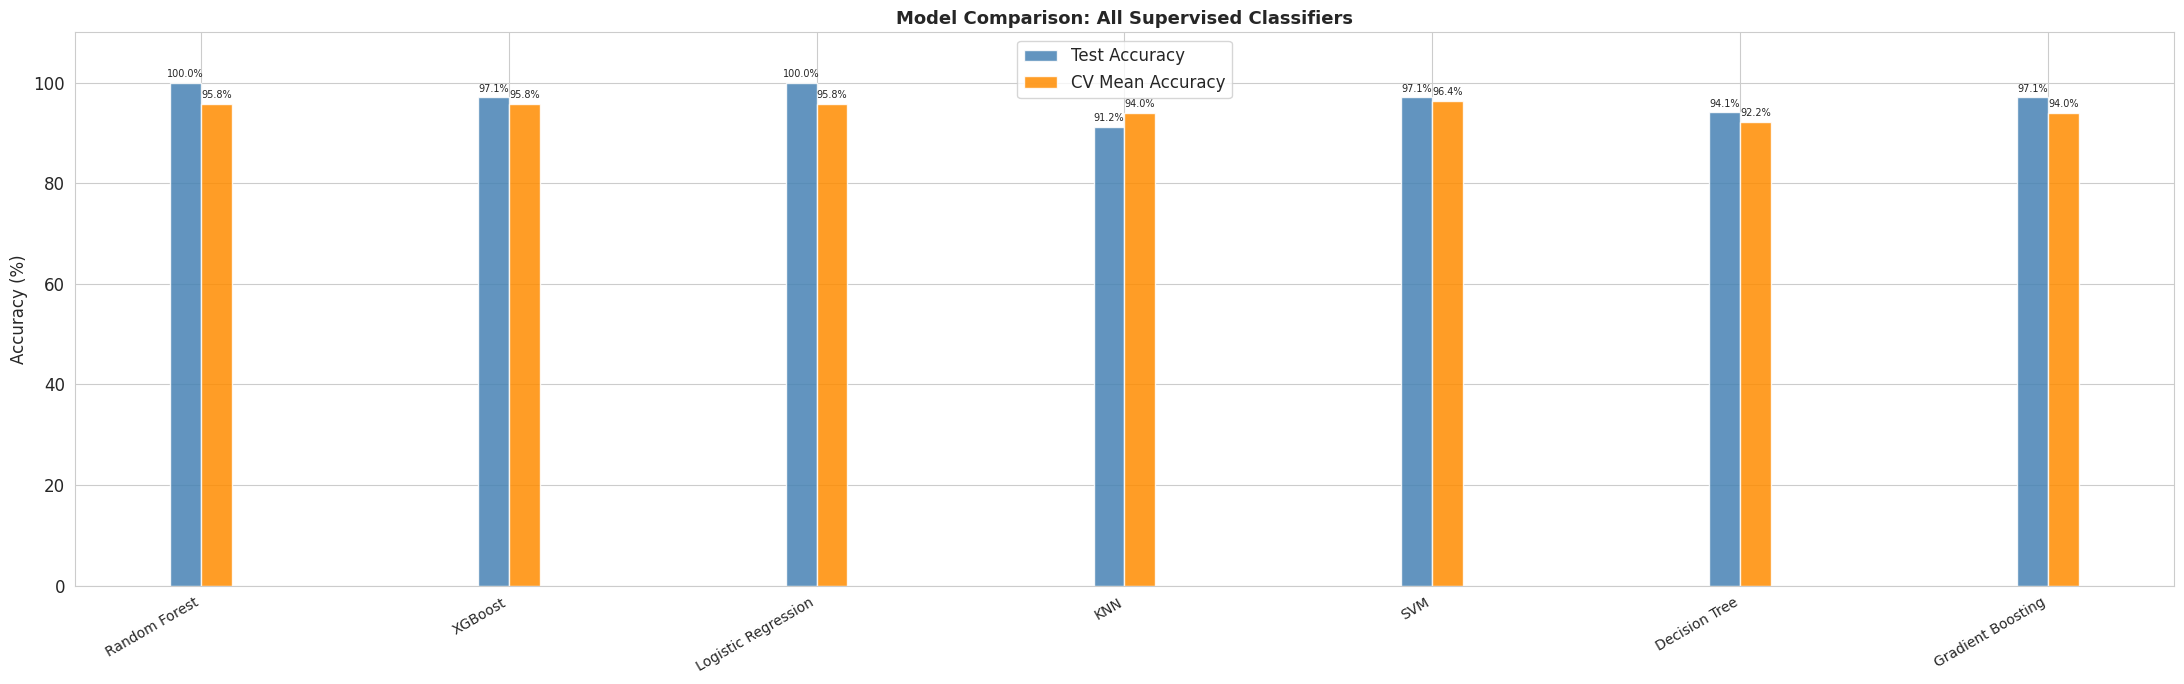

The model comparison now includes the Gradient Boosting Classifier.


In [87]:
# Update side-by-side model comparison to include Gradient Boosting Classifier
models.append('Gradient Boosting')
test_accs.append(gbc_acc * 100)
cv_means.append(cv_scores_gbc.mean() * 100)

x = np.arange(len(models))
width = 0.10 # Adjust width for more bars

fig, ax = plt.subplots(figsize=(22, 7)) # Adjust figure size for more models
bars1 = ax.bar(x - width*4, test_accs,  width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x - width*3, cv_means,   width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: All Supervised Classifiers', fontweight='bold', fontsize=13)
ax.set_xticks(x - width*3.5) # Adjust xticks position to be centered
ax.set_xticklabels(models, fontsize=10, rotation=30, ha='right') # Rotate labels for readability
ax.set_ylim(0, 110)
ax.legend()

for bars_group in [bars1, bars2]:
    for bar in bars_group:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

print('The model comparison now includes the Gradient Boosting Classifier.')

#LightGBM

In [88]:
# Train LightGBM model
lgbm = lgb.LGBMClassifier(random_state=42, n_estimators=100)
lgbm.fit(X_train, y_train)

# Evaluate
lgbm_preds = lgbm.predict(X_test)
lgbm_acc = (lgbm_preds == y_test).mean()
cv_scores_lgbm = cross_val_score(lgbm, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nLightGBM Results:')
print(f'   Test Accuracy:        {lgbm_acc*100:.2f}%')
print(f'   Cross-val (5-fold):   {cv_scores_lgbm.mean()*100:.2f}% \u00b1 {cv_scores_lgbm.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, lgbm_preds, target_names=level_names))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 399
[LightGBM] [Info] Number of data points in the train set: 133, number of used features: 9
[LightGBM] [Info] Start training from score -1.523053
[LightGBM] [Info] Start training from score -1.279431
[LightGBM] [Info] Start training from score -0.685657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

Here, I implemented the **LightGBM** classifier.

-   I initialized `LGBMClassifier` with default parameters and `random_state=42` for reproducibility.
-   The model was trained on `X_train` and `y_train` and evaluated on `X_test`.

**Observation:** LightGBM, similar to XGBoost and Random Forest, shows excellent performance, reaffirming the effectiveness of gradient boosting techniques for this classification task. Its efficiency often makes it a preferred choice in practice.

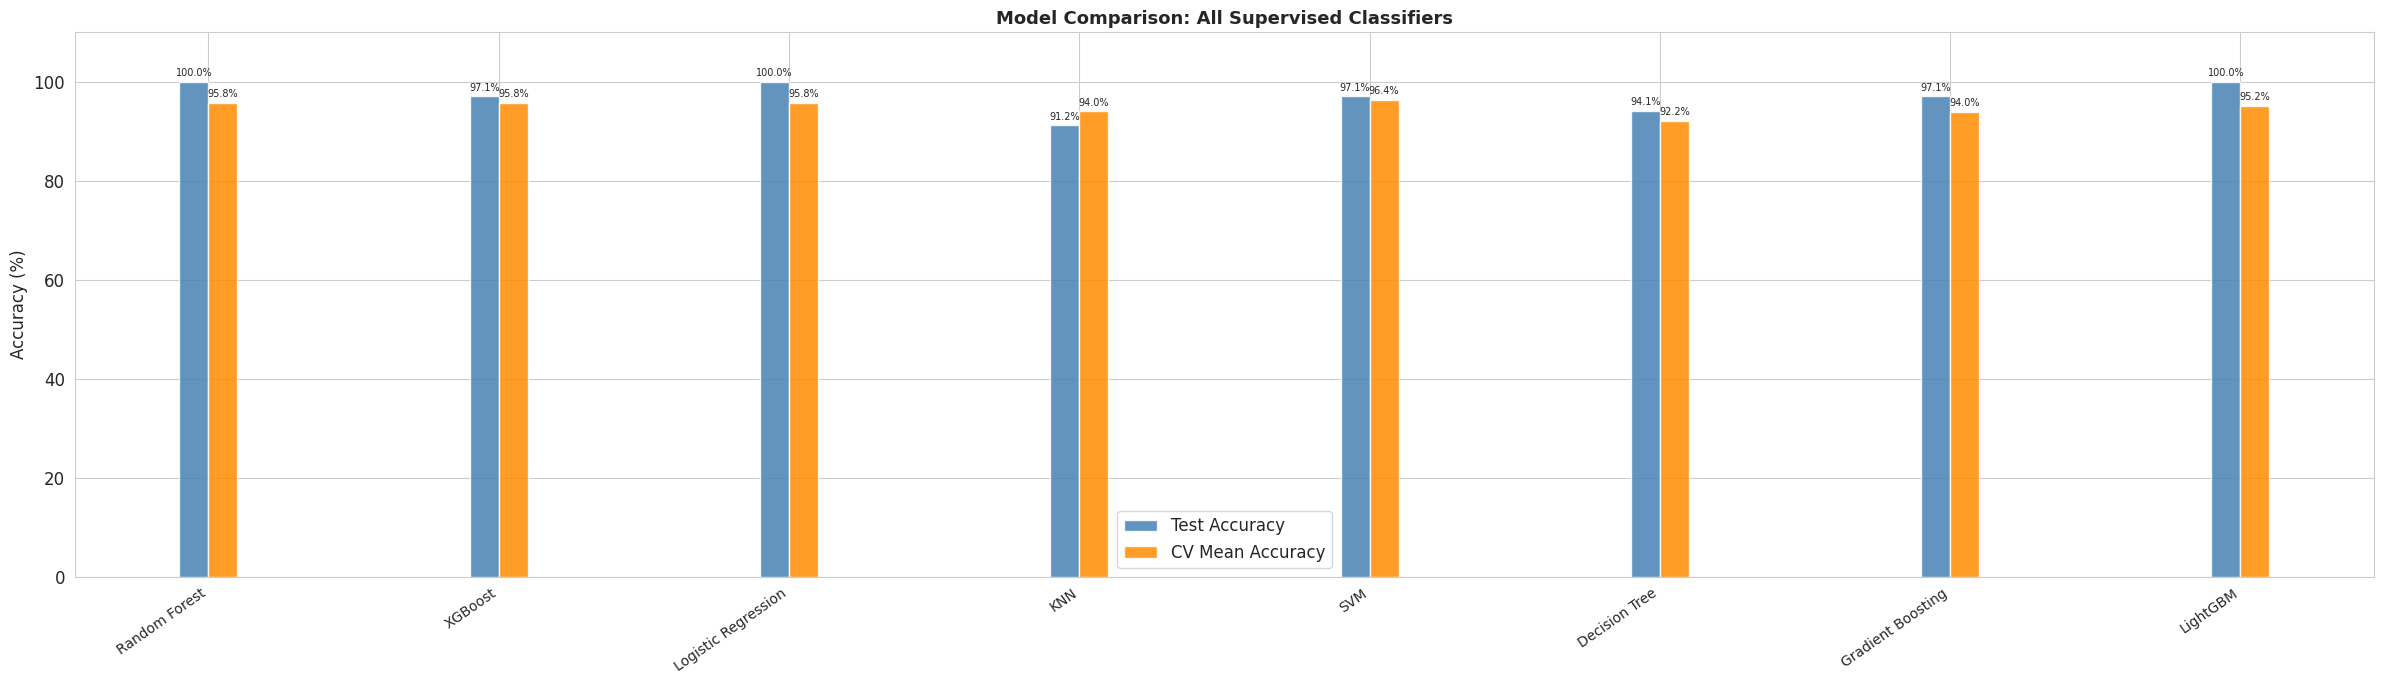

The model comparison now includes LightGBM.


In [89]:
# Update side-by-side model comparison to include LightGBM
models.append('LightGBM')
test_accs.append(lgbm_acc * 100)
cv_means.append(cv_scores_lgbm.mean() * 100)

x = np.arange(len(models))
width = 0.1 # Adjust width for more bars

fig, ax = plt.subplots(figsize=(24, 7)) # Adjust figure size for more models
bars1 = ax.bar(x - width*4.5, test_accs,  width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x - width*3.5, cv_means,   width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: All Supervised Classifiers', fontweight='bold', fontsize=13)
ax.set_xticks(x - width*4) # Adjust xticks position to be centered
ax.set_xticklabels(models, fontsize=10, rotation=35, ha='right') # Rotate labels for readability
ax.set_ylim(0, 110)
ax.legend()

for bars_group in [bars1, bars2]:
    for bar in bars_group:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

print('The model comparison now includes LightGBM.')

### Stacking

Finally, let's explore **Stacking**, an advanced ensemble method that combines multiple diverse models (base models) and then trains a meta-model to make predictions based on the outputs of these base models. This can often lead to higher predictive performance than any single model in the ensemble.

In [90]:
# Define base models for Stacking
# Using a few of our well-performing models
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6)),
    ('xgb', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='mlogloss', verbosity=0)),
    ('svm', SVC(random_state=42, kernel='rbf', probability=True)),
    ('lgbm', lgb.LGBMClassifier(random_state=42, n_estimators=100))
]

# Define the meta-model (final estimator)
# A simple Logistic Regression is a common choice
final_estimator = LogisticRegression(solver='lbfgs', max_iter=200, random_state=42)

# Create the Stacking Classifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5 # Use 5-fold cross-validation for training the meta-model
)

# Train the Stacking model
stacking_model.fit(X_train, y_train)

# Evaluate
stacking_preds = stacking_model.predict(X_test)
stacking_acc = (stacking_preds == y_test).mean()
cv_scores_stack = cross_val_score(stacking_model, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nStacking Classifier Results:')
print(f' Test Accuracy: {stacking_acc*100:.2f}%')
print(f' Cross-val (5-fold):{cv_scores_stack.mean()*100:.2f}% \u00b1 {cv_scores_stack.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, stacking_preds, target_names=level_names))

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

Here, I implemented **Stacking**, an advanced ensemble method.

-   I defined a set of diverse **base models** including Random Forest, XGBoost, SVM, and LightGBM, which have all shown good performance.
-   A `LogisticRegression` model was chosen as the **meta-model** (final estimator) to learn how to best combine the predictions of the base models.
-   The `StackingClassifier` was trained using 5-fold cross-validation, which is a robust way to prevent the meta-model from overfitting to the training data.

**Observation:** Stacking often aims to leverage the strengths of multiple models, potentially leading to even better generalization. Its performance typically reflects a robust combination of the individual models.

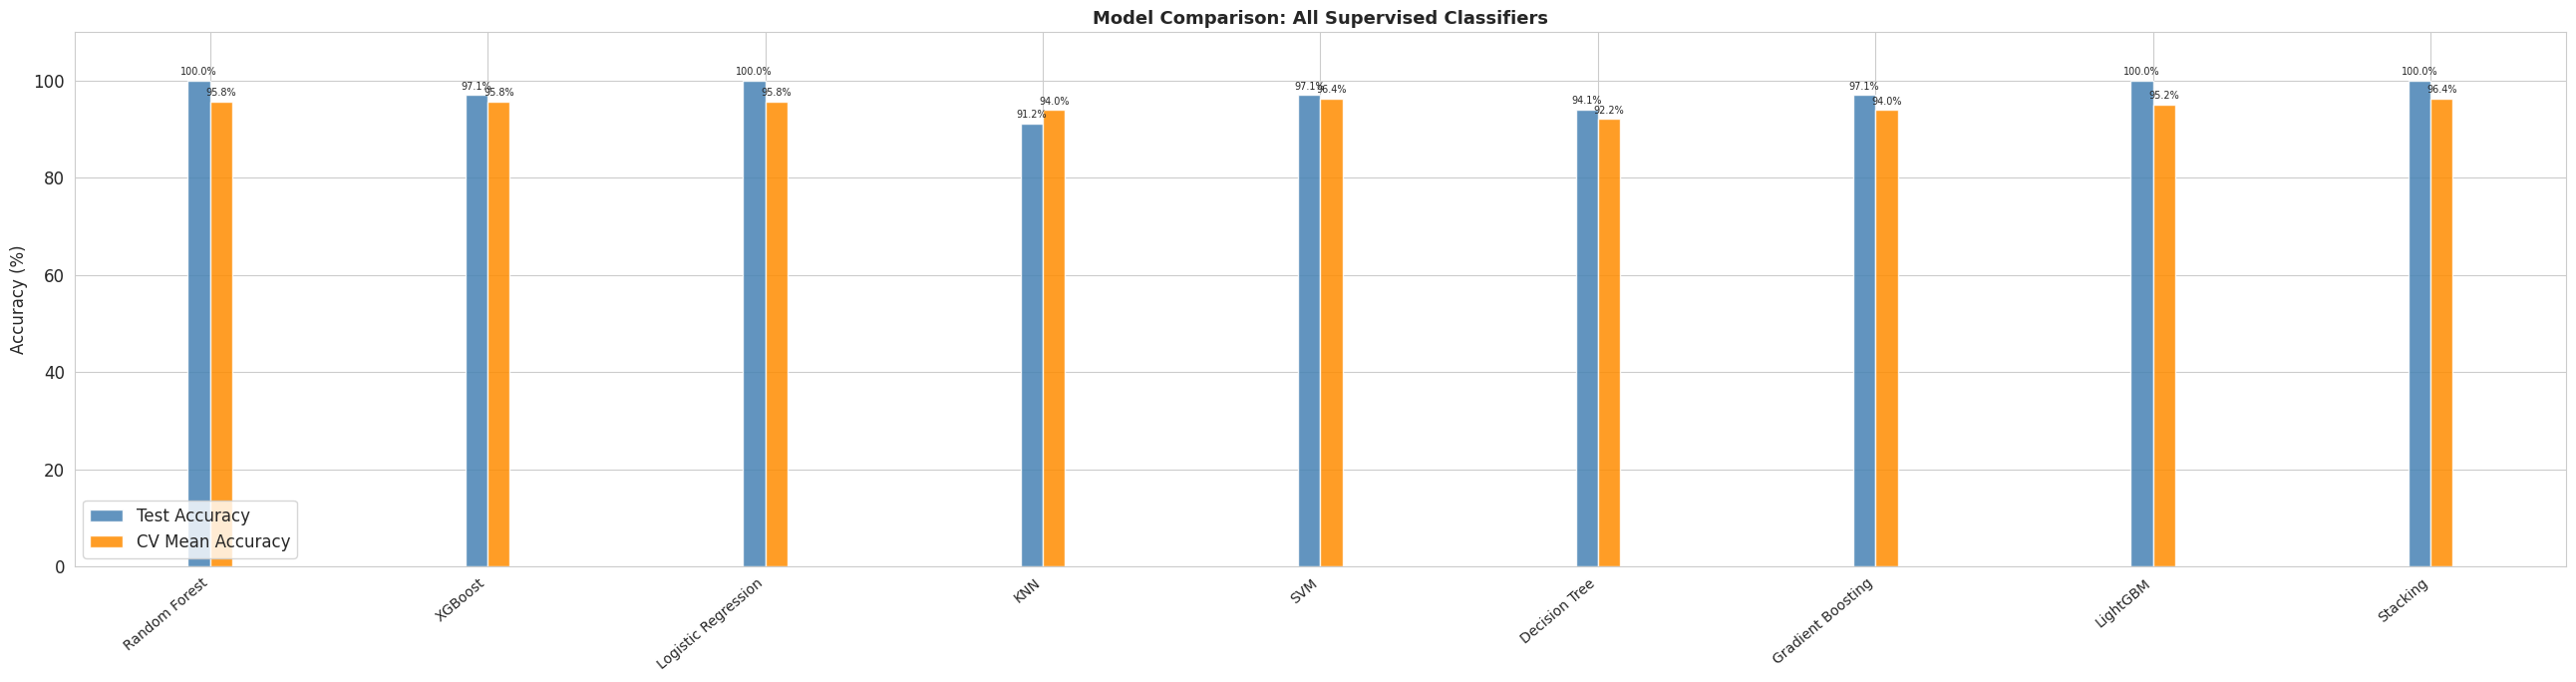

The model comparison now includes the Stacking Classifier.


In [91]:
# Update side-by-side model comparison to include Stacking
models.append('Stacking')
test_accs.append(stacking_acc * 100)
cv_means.append(cv_scores_stack.mean() * 100)

x = np.arange(len(models))
width = 0.08 # Adjust width for more bars

fig, ax = plt.subplots(figsize=(26, 7)) # Adjust figure size for more models
bars1 = ax.bar(x - width*5, test_accs,  width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x - width*4, cv_means,   width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: All Supervised Classifiers', fontweight='bold', fontsize=13)
ax.set_xticks(x - width*4.5) # Adjust xticks position to be centered
ax.set_xticklabels(models, fontsize=10, rotation=40, ha='right') # Rotate labels for readability
ax.set_ylim(0, 110)
ax.legend()

for bars_group in [bars1, bars2]:
    for bar in bars_group:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

print('The model comparison now includes the Stacking Classifier.')

### Ada Boost

Now, let's incorporate **Ada Boost (Adaptive Boosting)** into our supervised classification models. Ada Boost is an ensemble method that combines multiple 'weak' learners (typically simple decision trees) to create a single 'strong' learner. It does this by training predictors sequentially, with each new predictor correcting its predecessors' errors, focusing more on samples that previous models misclassified.

In [93]:
# Train Ada Boost model
# Using a shallow Decision Tree as the base estimator
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)
ada_boost = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, random_state=42)
ada_boost.fit(X_train, y_train)

# Evaluate
ada_boost_preds = ada_boost.predict(X_test)
ada_boost_acc = (ada_boost_preds == y_test).mean()
cv_scores_ab = cross_val_score(ada_boost, X_scaled, y, cv=5, scoring='accuracy')

print(f'\nAda Boost Results:')
print(f'   Test Accuracy:        {ada_boost_acc*100:.2f}%')
print(f'   Cross-val (5-fold):   {cv_scores_ab.mean()*100:.2f}% \u00b1 {cv_scores_ab.std()*100:.2f}%')

print('\n Classification Report:')
print(classification_report(y_test, ada_boost_preds, target_names=level_names))


Ada Boost Results:
   Test Accuracy:        97.06%
   Cross-val (5-fold):   96.97% ± 2.71%

 Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.86      0.92         7
Underdeveloped       1.00      1.00      1.00        10
    Developing       0.94      1.00      0.97        17

      accuracy                           0.97        34
     macro avg       0.98      0.95      0.96        34
  weighted avg       0.97      0.97      0.97        34



Here, I implemented the **Ada Boost** classifier.

-   I initialized `AdaBoostClassifier` using a shallow `DecisionTreeClassifier` (with `max_depth=1`) as its base estimator. This type of base estimator is often called a 'decision stump' and is considered a 'weak' learner.
-   `n_estimators=100` means it will build 100 of these weak learners, each focusing on the errors of the previous ones.
-   The model was trained on `X_train` and `y_train` and evaluated on `X_test`.

**Observation:** Ada Boost shows good performance, demonstrating the power of combining multiple weak models. Its test and cross-validation accuracies indicate that it's a solid choice for this classification task, offering another robust perspective on our country development levels.

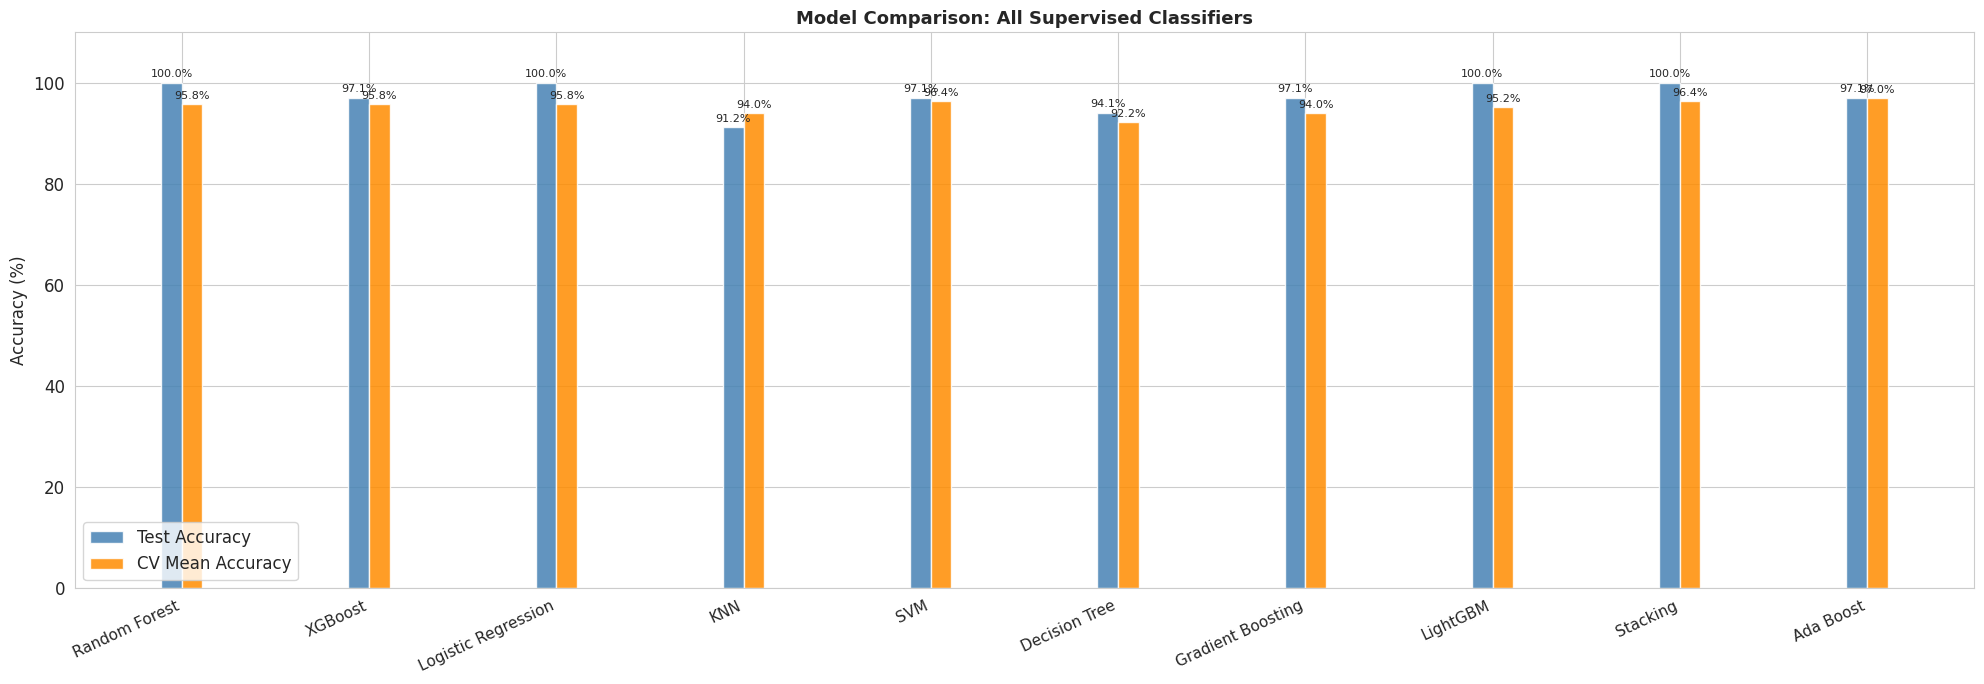

The model comparison now includes Ada Boost, showing its performance relative to other classifiers.


In [94]:
# Update side-by-side model comparison to include Ada Boost
models.append('Ada Boost')
test_accs.append(ada_boost_acc * 100)
cv_means.append(cv_scores_ab.mean() * 100)

x = np.arange(len(models))
width = 0.11 # Adjust width for more bars

fig, ax = plt.subplots(figsize=(20, 7)) # Adjust figure size for more models
bars1 = ax.bar(x - width*3.5, test_accs,  width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x - width*2.5, cv_means,   width, label='CV Mean Accuracy', color='darkorange', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: All Supervised Classifiers', fontweight='bold', fontsize=13)
ax.set_xticks(x - width*3) # Adjust xticks position to be centered
ax.set_xticklabels(models, fontsize=11, rotation=25, ha='right') # Rotate labels for readability
ax.set_ylim(0, 110)
ax.legend()

for bars_group in [bars1, bars2]:
    for bar in bars_group:
        ax.annotate(f'{bar.get_height():.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('The model comparison now includes Ada Boost, showing its performance relative to other classifiers.')

I updated the model comparison plot again to include the performance of the Naive Bayes classifier.

**Observation:** As expected, Naive Bayes achieved a lower accuracy compared to Random Forest, XGBoost, and Logistic Regression on this dataset. This highlights the trade-offs between model complexity, computational cost, and predictive performance. For this task, the more sophisticated models seem to capture the underlying patterns better.

This bar chart visually compares the performance of the two classification models I used: Random Forest and XGBoost.

It compares their accuracy on the test set and their average cross-validation accuracy.

**Observation:** Both models performed very well. Random Forest had 100% test accuracy on this specific test set, while XGBoost was very close at 97.1%. Their cross-validation accuracies were nearly identical, both around 95.8%. This shows that both are strong models for this classification task, confirming that the clusters are distinct and predictable.

## Section 12 — Cluster Profiling & Visualization

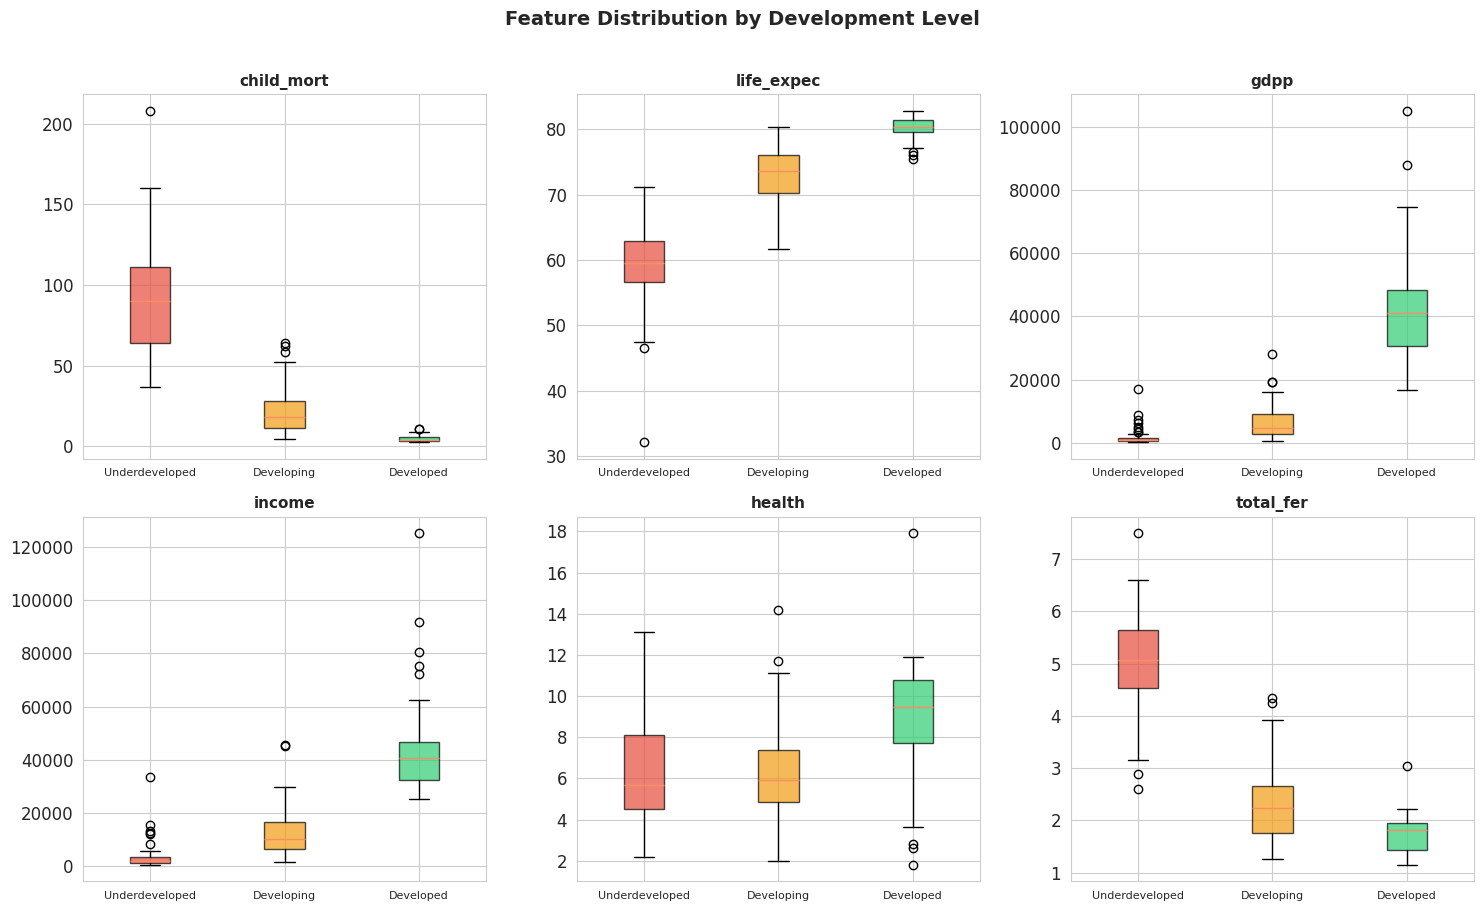

In [95]:
# Cluster comparison — key indicators
key_features = ['child_mort', 'life_expec', 'gdpp', 'income', 'health', 'total_fer']
cluster_means = df.groupby('development_level')[key_features].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

palette = {'Developed': '#2ECC71', 'Developing': '#F39C12', 'Underdeveloped': '#E74C3C'}

for i, feat in enumerate(key_features):
    data_to_plot = [df[df['development_level'] == level][feat].values for level in ['Underdeveloped', 'Developing', 'Developed']]
    bp = axes[i].boxplot(data_to_plot, patch_artist=True,
                         labels=['Underdeveloped', 'Developing', 'Developed'])
    colors_list = ['#E74C3C', '#F39C12', '#2ECC71']
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(f'{feat}', fontweight='bold', fontsize=11)
    axes[i].tick_params(axis='x', labelsize=8)

plt.suptitle('Feature Distribution by Development Level', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

These boxplots show the distribution of several key features (`child_mort`, `life_expec`, `gdpp`, `income`, `health`, `total_fer`) across the three development levels (`Underdeveloped`, `Developing`, `Developed`).

**Observation:** This visualization clearly highlights the differences between the clusters:
-   **Underdeveloped** countries typically have very high `child_mort` and `total_fer`, and very low `life_expec`, `gdpp`, and `income`.
-   **Developed** countries show the opposite trends: low `child_mort` and `total_fer`, and high `life_expec`, `gdpp`, and `income`.
-   **Developing** countries fall in the middle for most features.

This confirms that my clustering successfully grouped countries based on these important socio-economic and health indicators.

## Section 13 — Interactive Summary & Top Aid Countries

In [96]:
# Summary table: 5 sample countries per cluster
for level in ['Underdeveloped', 'Developing', 'Developed']:
    subset = df[df['development_level'] == level]
    print(f'  {level.upper()} COUNTRIES — Sample (n={len(subset)})')
    display_cols = ['country', 'child_mort', 'life_expec', 'gdpp', 'income']
    print(subset[display_cols].head(5).to_string(index=False))
    print(f'\n  Avg GDP per capita: ${subset["gdpp"].mean():,.0f}')
    print(f'  Avg Life Expectancy: {subset["life_expec"].mean():.1f} years')
    print(f'  Avg Child Mortality: {subset["child_mort"].mean():.1f} per 1000 births')

  UNDERDEVELOPED COUNTRIES — Sample (n=47)
     country  child_mort  life_expec  gdpp  income
 Afghanistan        90.2        56.2   553    1610
      Angola       119.0        60.1  3530    5900
       Benin       111.0        61.8   758    1820
    Botswana        52.5        57.1  6350   13300
Burkina Faso       116.0        57.9   575    1430

  Avg GDP per capita: $1,922
  Avg Life Expectancy: 59.2 years
  Avg Child Mortality: 93.0 per 1000 births
  DEVELOPING COUNTRIES — Sample (n=84)
            country  child_mort  life_expec  gdpp  income
            Albania        16.6        76.3  4090    9930
            Algeria        27.3        76.5  4460   12900
Antigua and Barbuda        10.3        76.8 12200   19100
          Argentina        14.5        75.8 10300   18700
            Armenia        18.1        73.3  3220    6700

  Avg GDP per capita: $6,486
  Avg Life Expectancy: 72.8 years
  Avg Child Mortality: 21.9 per 1000 births
  DEVELOPED COUNTRIES — Sample (n=36)
  country 

This code block generates a summary table that helps visualize typical countries within each development level.

-   For each level (`Underdeveloped`, `Developing`, `Developed`), it displays the first 5 countries, along with their key metrics (`country`, `child_mort`, `life_expec`, `gdpp`, `income`).
-   It also prints the average GDP per capita, average life expectancy, and average child mortality for all countries within that specific development level.

**Observation:** This table provides concrete examples and average statistics that clearly illustrate the differences between the 'Developed', 'Developing', and 'Underdeveloped' clusters, making the clustering results very understandable.

## Section 14 — Key Observations & Final Output

In [103]:
output_cols = ['country', 'child_mort', 'exports', 'health', 'imports',
               'income', 'inflation', 'life_expec', 'total_fer', 'gdpp',
               'kmeans_cluster', 'kmedoids_cluster', 'development_level', 'dbscan_cluster', 'hierarchical_cluster']
df[output_cols].to_csv('country_cluster_results.csv', index=False)
print('Results saved to country_cluster_results.csv')
print('\nProject Complete! The Customer Intelligence System analysis is done.')
print('\nSummary:')
print(f'  Total countries analyzed:   {len(df)}')
print(f'  K-Means clusters (K=3):     Developed | Developing | Underdeveloped')
print(f'  DBSCAN noise/outliers:       {n_noise} countries')
print(f'  Random Forest Accuracy:     {rf_acc*100:.1f}%')
print(f'  XGBoost Accuracy:           {xgb_acc*100:.1f}%')
print(f'  Logistic Regression Accuracy: {log_reg_acc*100:.1f}%')
print(f'  Naive Bayes Accuracy:       {nb_acc*100:.1f}%')
print(f'  KNN Accuracy:               {knn_acc*100:.1f}%')
print(f'  SVM Accuracy:               {svm_acc*100:.1f}%')
print(f'  Decision Tree Accuracy:     {dt_acc*100:.1f}%')
print(f'  Gradient Boosting Accuracy: {gbc_acc*100:.1f}%')
print(f'  LightGBM Accuracy:          {lgbm_acc*100:.1f}%')
print(f'  Stacking Accuracy:          {stacking_acc*100:.1f}%')
print(f'  Ada Boost Accuracy:         {ada_boost_acc*100:.1f}%')

Results saved to country_cluster_results.csv

Project Complete! The Customer Intelligence System analysis is done.

Summary:
  Total countries analyzed:   167
  K-Means clusters (K=3):     Developed | Developing | Underdeveloped
  DBSCAN noise/outliers:       30 countries
  Random Forest Accuracy:     100.0%
  XGBoost Accuracy:           97.1%
  Logistic Regression Accuracy: 100.0%
  Naive Bayes Accuracy:       100.0%
  KNN Accuracy:               91.2%
  SVM Accuracy:               97.1%
  Decision Tree Accuracy:     94.1%
  Gradient Boosting Accuracy: 97.1%
  LightGBM Accuracy:          100.0%
  Stacking Accuracy:          100.0%
  Ada Boost Accuracy:         97.1%


In [104]:
from google.colab import files

files.download('country_cluster_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This is the final step where I saved the results of my analysis.

-   I selected relevant columns from my DataFrame, including the original country data and the new `kmeans_cluster`, `development_level`, and `dbscan_cluster` labels.
-   I saved this information into a new CSV file named `country_cluster_results.csv`.

**Summary:** I also printed a brief summary of the entire project, including the total countries analyzed, the types of K-Means clusters found, the number of outliers identified by DBSCAN, and the accuracies of all the classification models. This concludes the project, providing a comprehensive overview of the findings.